<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Librerias

In [ ]:
# Instalar gdown (solo es necesario la primera vez)
#!pip install gdown
# Descargar la carpeta con los datos
!gdown --folder --id 1GOJ63mZ6qZGdbb8v5v6bcy3fsbLs8yju
# Cargar el dataset en un DataFrame
import pandas as pd
df = pd.read_pickle('data/house_prices.pkl')

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Retrieving folder contents
Processing file 1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG data_description.txt
Processing file 1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF house_prices.pkl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG
To: /content/data/data_description.txt
100% 13.4k/13.4k [00:00<00:00, 32.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF
To: /content/data/house_prices.pkl
100% 140k/140k [00:00<00:00, 95.7MB/s]
Download completed


In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.6/107.6 kB 1.0 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from category_encoders import BinaryEncoder

# Ames, Iowa

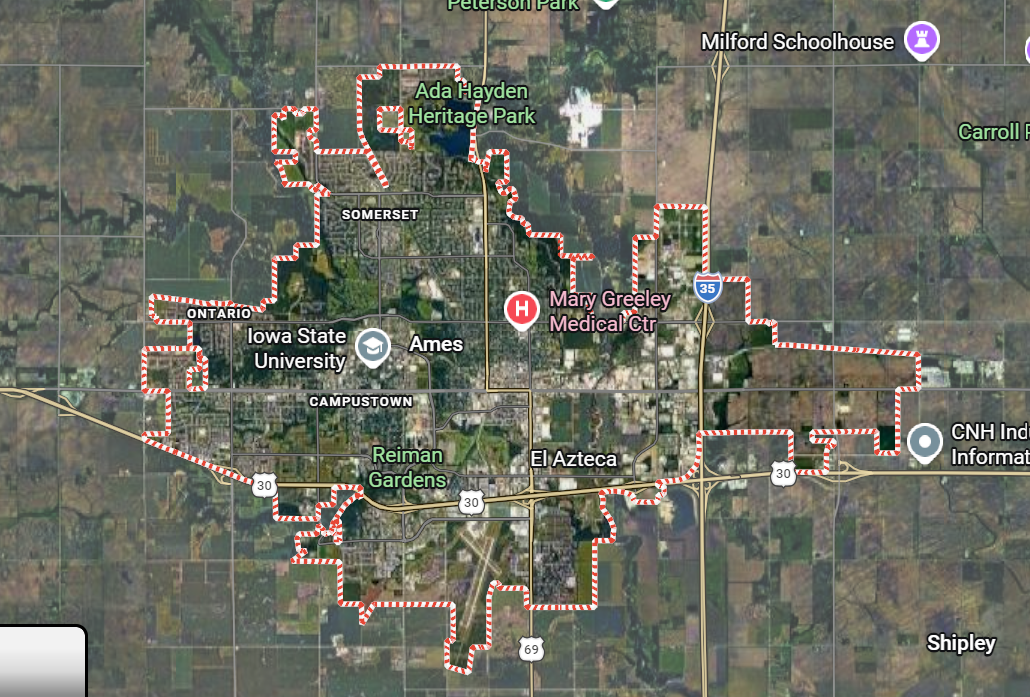

#Ejercicio 1

##Seccion 1.1

In [ ]:
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")


Dimensiones del dataset: 1487 filas, 14 columnas


Resumen de variables

Las variables corresponden al dataset de Ames Housing (comúnmente usado en la competencia *House Prices* de Kaggle):

* **SalePrice:** Precio de venta de la propiedad en dólares (variable objetivo / target).
* **MSZoning:** Clasificación general de zonificación del terreno (ej. residencial de baja densidad 'RL', residencial de media densidad 'RM', comercial 'C', etc.).
* **Neighborhood:** Ubicación física o barrio dentro de los límites de la ciudad de Ames (ej. `NAmes`, `CollgCr`, `OldTown`).
* **LotFrontage:** Longitud lineal en pies (ft) de la calle conectada con la propiedad (frente del lote).
* **LotArea:** Tamaño total del lote o terreno en pies cuadrados ($ft^2$).
* **OverallCond:** Calificación general del estado/condición de la vivienda en una escala del 1 (muy pobre) al 10 (muy excelente).
* **YearBuilt:** Año original de construcción de la propiedad.
* **FullBath:** Cantidad de baños completos ubicados por encima del nivel del suelo (*above ground*).
* **BedroomAbvGr:** Cantidad de dormitorios ubicados por encima del nivel del suelo (excluye dormitorios en el sótano/basement).
* **GarageQual:** Calidad del garaje (ej. `Ex` Excelente, `Gd` Bueno, `TA` Típico/Promedio, `Fa` Regular, `Po` Pobre, `NA` Sin garaje).
* **GarageArea:** Tamaño total del garaje en pies cuadrados ($ft^2$).
* **PoolArea:** Superficie de la piscina en pies cuadrados ($ft^2$).
* **PoolQC:** Calidad de la piscina (ej. `Ex`, `Gd`, `TA`, `Fa`, `NA` si no tiene piscina).
* **Fence:** Calidad y privacidad de la cerca o cercado (ej. `GdPrv` Buena privacidad, `MnPrv` Mínima privacidad, `GdWo` Buena madera, `MnWw` Mínima madera/alambre, `NA` Sin cerca).


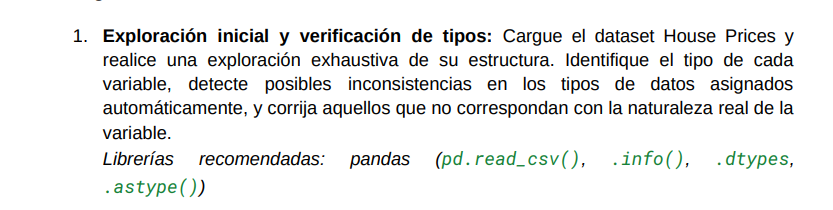

In [ ]:
df.head()

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NaN,NaN
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NaN,NaN
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
3,307000,rL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NaN,NaN
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NaN,NaN


In [ ]:
def armar_resumen(df):

  """Construye la tabla de resumen de tipos y faltantes, manteniendo
  el % como numérico (para poder aplicarle color o graficarlo después)."""

  faltantes = df.isna().sum() + (df == 'NONE').sum()

  resumen = pd.DataFrame({

      'Tipo de Dato': df.dtypes.astype(str),

      'Datos Válidos (No Nulos)': len(df) - faltantes,

      'Datos Faltantes (Nulos)': faltantes,

      '% de Faltantes': (faltantes / len(df) * 100).round(2),

  })

  return resumen.sort_values(by='Datos Faltantes (Nulos)', ascending=False)


def graficar_faltantes(resumen, umbral=0):
  """Barra horizontal con el % de faltantes por columna, para tener
  una lectura visual rápida antes de entrar al detalle de la tabla.
  umbral filtra columnas con menos de ese % (para no saturar el gráfico
  con columnas que tienen 0 o casi 0 faltantes)."""
  datos = resumen[resumen['% de Faltantes'] > umbral].sort_values('% de Faltantes')
  fig, ax = plt.subplots(figsize=(8, max(3, len(datos) * 0.3)))
  ax.barh(datos.index, datos['% de Faltantes'], color='#D85A30')
  ax.set_xlabel('% de Faltantes')
  ax.set_title('Variables con valores faltantes')
  for i, v in enumerate(datos['% de Faltantes']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
  plt.tight_layout()
  plt.show()


def explorar_categoricas(df, columnas=None, top_n=10):
  """Muestra value_counts de cada columna categórica, para detectar
  inconsistencias de nomenclatura (mayúsculas, espacios, typos) —
  consigna 1.2. Si no se pasan columnas, usa todas las object/category."""
  if columnas is None:
    columnas = df.select_dtypes(include=['object', 'category']).columns
  for col in columnas:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).head(top_n))
    print()

def graficar_antes_despues_categorias(antes_crudo, despues, orden_final,
                                        categoria_nueva='NONE',
                                        categorias_fusionadas=('NA', 'NAN')):
  """Grafica en dos paneles lado a lado la distribución de una variable
  categórica: a la izquierda, las categorías originales (incluyendo el
  faltante real, mostrado como 'NAN', y la categoría de texto 'NA' por
  separado); a la derecha, la distribución final ya unificada. Resalta
  en color distinto las categorías afectadas por la transformación."""

  normalizado = antes_crudo.astype('string').str.strip().str.upper()
  normalizado = normalizado.fillna('NAN')
  conteo_antes = normalizado.value_counts().sort_values(ascending=False)

  conteo_despues = despues.value_counts().reindex(orden_final, fill_value=0)

  color_normal, color_afectado = '#5F5E5A', '#D85A30'
  colores_antes = [color_afectado if c in categorias_fusionadas else color_normal for c in conteo_antes.index]
  colores_despues = [color_afectado if c == categoria_nueva else color_normal for c in conteo_despues.index]

  fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

  axes[0].barh(conteo_antes.index.astype(str), conteo_antes.values, color=colores_antes)
  axes[0].invert_yaxis()
  axes[0].set_title('Antes: categorías originales')
  axes[0].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_antes.values):
    axes[0].text(v + max(conteo_antes.values) * 0.01, i, str(v), va='center', fontsize=9)

  axes[1].barh(conteo_despues.index.astype(str), conteo_despues.values, color=colores_despues)
  axes[1].invert_yaxis()
  axes[1].set_title('Después: categorías unificadas')
  axes[1].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_despues.values):
    axes[1].text(v + max(conteo_despues.values) * 0.01, i, str(v), va='center', fontsize=9)

  plt.tight_layout()
  plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   SalePrice     1487 non-null   object
 1   MSZoning      1487 non-null   object
 2   Neighborhood  1487 non-null   object
 3   LotFrontage   1233 non-null   object
 4   LotArea       1487 non-null   int64 
 5   OverallCond   1487 non-null   int64 
 6   YearBuilt     1487 non-null   int64 
 7   FullBath      1487 non-null   int64 
 8   BedroomAbvGr  1487 non-null   int64 
 9   GarageQual    1411 non-null   object
 10  GarageArea    1487 non-null   int64 
 11  PoolArea      1487 non-null   int64 
 12  PoolQC        7 non-null      object
 13  Fence         298 non-null    object
dtypes: int64(7), object(7)
memory usage: 162.8+ KB


In [ ]:
df['SalePrice'] = df['SalePrice'].astype(int)
df['LotFrontage'] = pd.to_numeric(df['LotFrontage'], errors='coerce')

#Chequeamos que son int64 y float64 respectivamente
assert df['SalePrice'].dtype == 'int64'
assert df['LotFrontage'].dtype == 'float64'

resumen = armar_resumen(df)

display(resumen)

,Tipo de Dato,Datos Válidos (No Nulos),Datos Faltantes (Nulos),% de Faltantes
PoolQC,object,7,1480,99.53
Fence,object,298,1189,79.96
LotFrontage,float64,1223,264,17.75
GarageQual,object,1411,76,5.11
MSZoning,object,1487,0,0.00
SalePrice,int64,1487,0,0.00
OverallCond,int64,1487,0,0.00
LotArea,int64,1487,0,0.00
Neighborhood,object,1487,0,0.00
YearBuilt,int64,1487,0,0.00


Despues de realizar un analisis de la estructura del dataset y los tipos de datos para cada variable, podemos agruparlas de la siguiente manera:

**Numericas**

*   SalePrice
* LotArea
* YearBuilt
* BedroomAbvGR
* FullBath
* PoolArea
* GarageArea
* LotFrontage (en todos los registros, la parte decimal es 0)

**Categoricas**

Nominales:
*   NeighborHood
*   MSZoning

Ordinales:
*   OverallCond (codificada numericamente)
* GarageQual
* PoolQC
* Fence








##Seccion 1.2

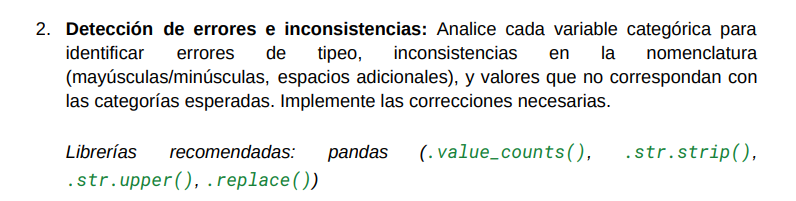

In [ ]:
#Fence
df_antes = df['Fence'].copy()

In [ ]:
df['Fence'].value_counts(dropna = False)

#En esta variable vemos que hay dos registros que se refieren a lo mismo (Nan y nan). Por eso primero vamos a juntarlos todos con el mismo nombre, ya
#que ambos hacen referencia a casas que no tienen un cercado y despues les pondremos el nombre 'NONE' para mantener la consistencia en el dataset



,count
Fence,
NONE,1180
MnPrv,158
GdPrv,59
GdWo,54
MnWw,11


In [ ]:
#Eliminamos espacios en blanco y volvemos a probar
df['Fence']  = df['Fence'].str.strip()

#Comprobamos que realmente se tratan de cadenas de texto y no de valores nulos reales
df_filtrado = df[df['Fence'] == 'nan']

df_filtrado.head()

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence


In [ ]:
#Ahora si reemplazamos y unificamos
df['Fence'] = df['Fence'].replace({'nan' : 'NONE'})
df['Fence'].value_counts()

df['Fence'].value_counts(dropna = False)


,count
Fence,
NONE,1180
MnPrv,158
GdPrv,59
GdWo,54
MnWw,11


In [ ]:
#Finalmente, unificamos con los NaN almacenados como NaN reales bajo el nombre "NONE"
df['Fence'] = df['Fence'].fillna('NONE')
df['Fence'].value_counts(dropna = False)

,count
Fence,
NONE,1180
MnPrv,158
GdPrv,59
GdWo,54
MnWw,11


In [ ]:
def graficar_antes_despues_categorias_alternativo(antes_crudo, despues, orden_final,
                                        categoria_nueva='NONE',
                                        categorias_fusionadas=('NA', 'NAN')):
  """Grafica en dos paneles lado a lado la distribución de una variable
  categórica: a la izquierda, las categorías originales (incluyendo el
  faltante real, mostrado como 'NAN', y la categoría de texto 'NA' por
  separado); a la derecha, la distribución final ya unificada. Resalta
  en color distinto las categorías afectadas por la transformación."""

  normalizado = antes_crudo.astype('string').str.strip()
  normalizado = normalizado.fillna('NaN')

  conteo_antes = normalizado.value_counts().sort_values(ascending=False)

  conteo_despues = despues.value_counts().reindex(orden_final, fill_value=0)

  color_normal, color_afectado = '#5F5E5A', '#D85A30'
  colores_antes = [color_afectado if c in categorias_fusionadas else color_normal for c in conteo_antes.index]
  colores_despues = [color_afectado if c == categoria_nueva else color_normal for c in conteo_despues.index]

  fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

  axes[0].barh(conteo_antes.index.astype(str), conteo_antes.values, color=colores_antes)
  axes[0].invert_yaxis()
  axes[0].set_title('Antes: categorías originales')
  axes[0].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_antes.values):
    axes[0].text(v + max(conteo_antes.values) * 0.01, i, str(v), va='center', fontsize=9)

  axes[1].barh(conteo_despues.index.astype(str), conteo_despues.values, color=colores_despues)
  axes[1].invert_yaxis()
  axes[1].set_title('Después: categorías unificadas')
  axes[1].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_despues.values):
    axes[1].text(v + max(conteo_despues.values) * 0.01, i, str(v), va='center', fontsize=9)

  plt.tight_layout()
  plt.show()

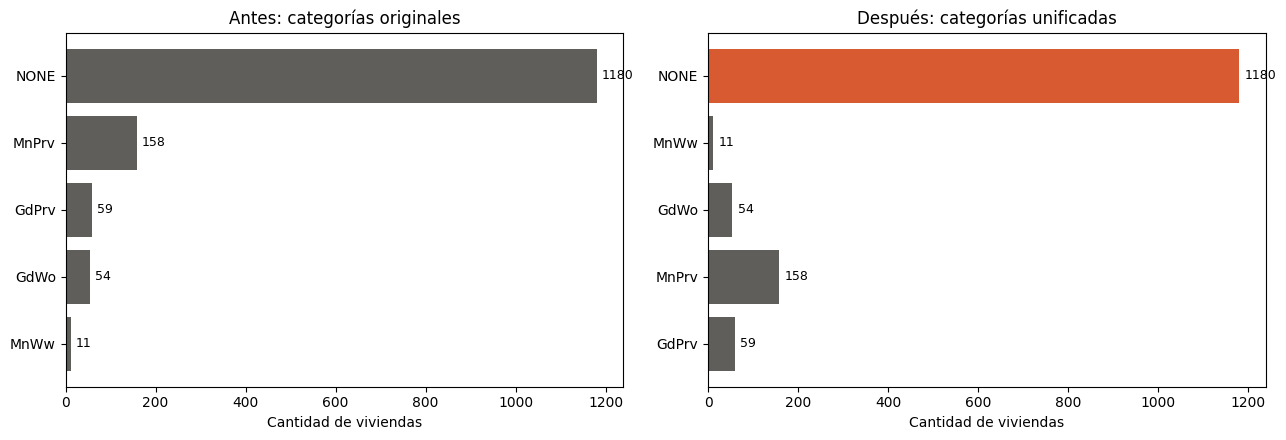

In [ ]:
graficar_antes_despues_categorias_alternativo(
    antes_crudo=df_antes,
    despues=df['Fence'],
    orden_final=['NONE', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']
)

In [ ]:
#Neighborhood
df_antes = df['Neighborhood'].copy()
print('Frecuencias originales:')
print(df['Neighborhood'].value_counts())

#Al comparar los resultados con la documentacion oficial del dataset, todos los registros estan correctos excepto dos. Al final de la lista se repiten
#'NAmes' y 'BrkSide'

#Verificamos si hay algun espacio en blanco
df['Neighborhood']  = df['Neighborhood'].str.strip()
print('\nFrecuencias despues de aplicar str.strip():')
df['Neighborhood'].value_counts()

#Podemos comprobar que efectivamente los 3 registros adicionales se debian a la presencai de espacios en blanco en los registros, por lo que ya estan bien unificados

Frecuencias originales:
Neighborhood
NAmes      225
CollgCr    152
OldTown    113
Edwards     99
Somerst     86
Gilbert     79
NridgHt     77
NWAmes      74
Sawyer      74
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

Frecuencias despues de aplicar str.strip():


,count
Neighborhood,
NAmes,225
CollgCr,152
OldTown,113
Edwards,99
Somerst,86
Gilbert,79
NridgHt,77
NWAmes,74
Sawyer,74


In [ ]:
def graficar_antes_despues_neighborhood(antes_crudo, despues, orden_final):
    """Grafica Neighborhood antes y después de eliminar espacios."""

    #Colores: mismo estilo que GarageQual
    color_normal = '#5F5E5A'
    color_afectado = '#D85A30'

    #Antes: conservamos las categorías originales
    conteo_antes = antes_crudo.astype('string').value_counts(dropna=False)

    #Después
    conteo_despues = despues.value_counts().reindex(
        orden_final, fill_value=0
    )

    # Detectamos qué categorías estaban afectadas por espacios
    categorias_afectadas = set(
        antes_crudo.dropna().loc[
            antes_crudo.dropna().str.strip() != antes_crudo.dropna()
        ].str.strip()
    )

    colores_antes = [
        color_afectado if str(c).strip() in categorias_afectadas
        else color_normal
        for c in conteo_antes.index
    ]

    colores_despues = [
        color_afectado if c in categorias_afectadas
        else color_normal
        for c in conteo_despues.index
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 8))

    # --- ANTES ---
    axes[0].barh(
        conteo_antes.index.astype(str),
        conteo_antes.values,
        color=colores_antes
    )

    axes[0].invert_yaxis()
    axes[0].set_title('Antes: categorías originales')
    axes[0].set_xlabel('Cantidad de viviendas')

    for i, v in enumerate(conteo_antes.values):
        axes[0].text(
            v + max(conteo_antes.values) * 0.01,
            i,
            str(v),
            va='center',
            fontsize=9
        )

    # --- DESPUÉS ---
    axes[1].barh(
        conteo_despues.index.astype(str),
        conteo_despues.values,
        color=colores_despues
    )

    axes[1].invert_yaxis()
    axes[1].set_title('Después: categorías unificadas')
    axes[1].set_xlabel('Cantidad de viviendas')

    for i, v in enumerate(conteo_despues.values):
        axes[1].text(
            v + max(conteo_despues.values) * 0.01,
            i,
            str(v),
            va='center',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

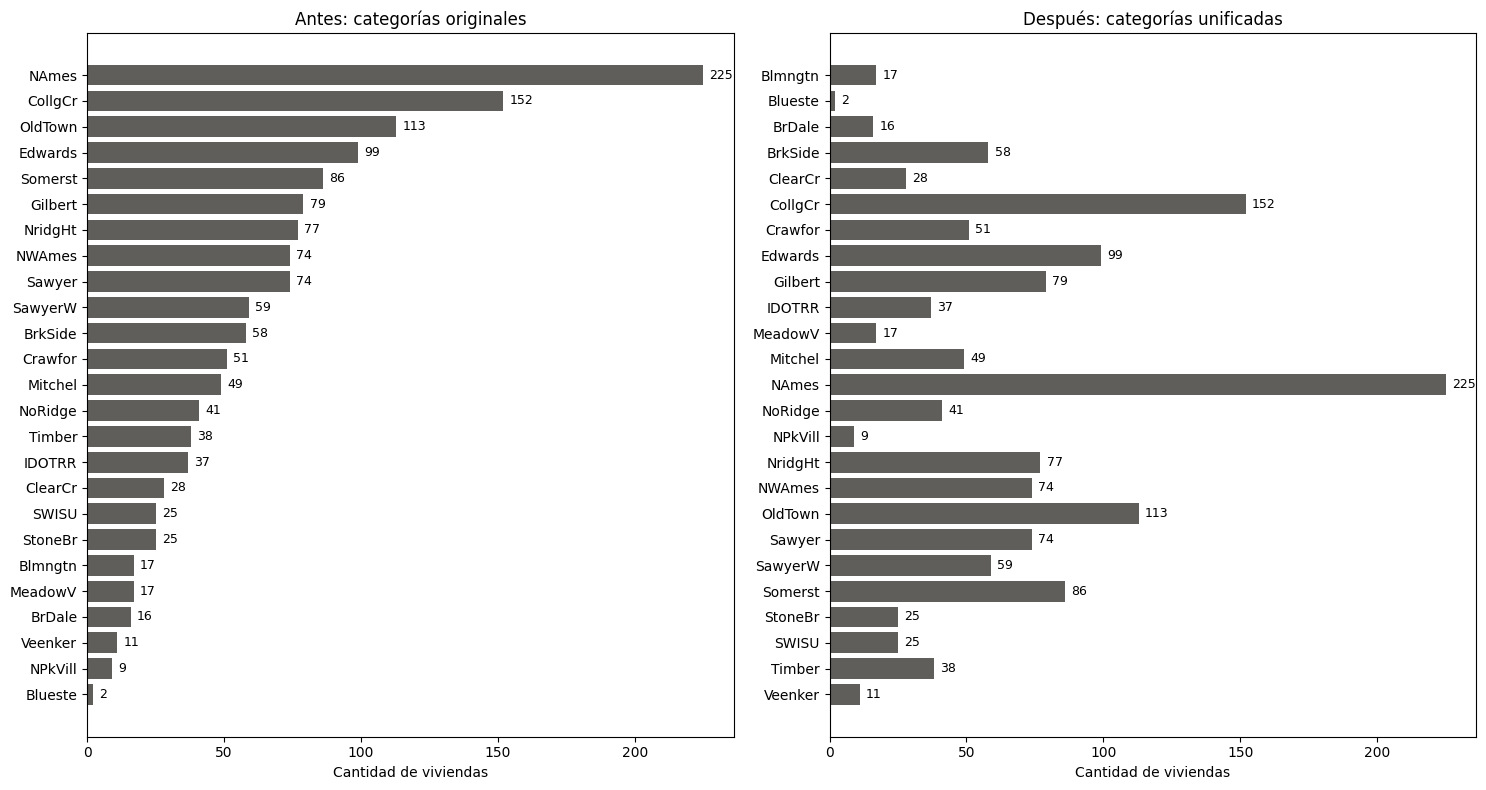

In [ ]:
graficar_antes_despues_neighborhood(
    antes_crudo=df_antes,
    despues=df['Neighborhood'],
    orden_final=[
        'Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr',
        'CollgCr', 'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR',
        'MeadowV', 'Mitchel', 'NAmes', 'NoRidge', 'NPkVill',
        'NridgHt', 'NWAmes', 'OldTown', 'Sawyer', 'SawyerW',
        'Somerst', 'StoneBr', 'SWISU', 'Timber', 'Veenker'
    ]
)

In [ ]:
#MSZoning
df['MSZoning'].value_counts()

#Comparando con la documentacion oficial, todos los registros tendrian que estar en mayuscula. Sin embargo, en el dataset hay registros que hacen referencia
# a las zonas correctas pero escritas en minuscula


,count
MSZoning,
RL,1153
RM,218
FV,65
RH,16
C (ALL),10


In [ ]:
#Ponemos todo en mayusculas
df['MSZoning'] = df['MSZoning'].str.upper()

df['MSZoning'].value_counts()

,count
MSZoning,
RL,1153
RM,218
FV,65
RH,16
C (ALL),10


Frecuencias originales:
GarageQual
TA      1313
NONE      81
FA        48
GD        14
PO         3
EX         3
Name: count, dtype: int64

Frecuencias después de unificar los nulos:
GarageQual
TA      1313
NONE      81
FA        48
GD        14
PO         3
EX         3
Name: count, dtype: int64


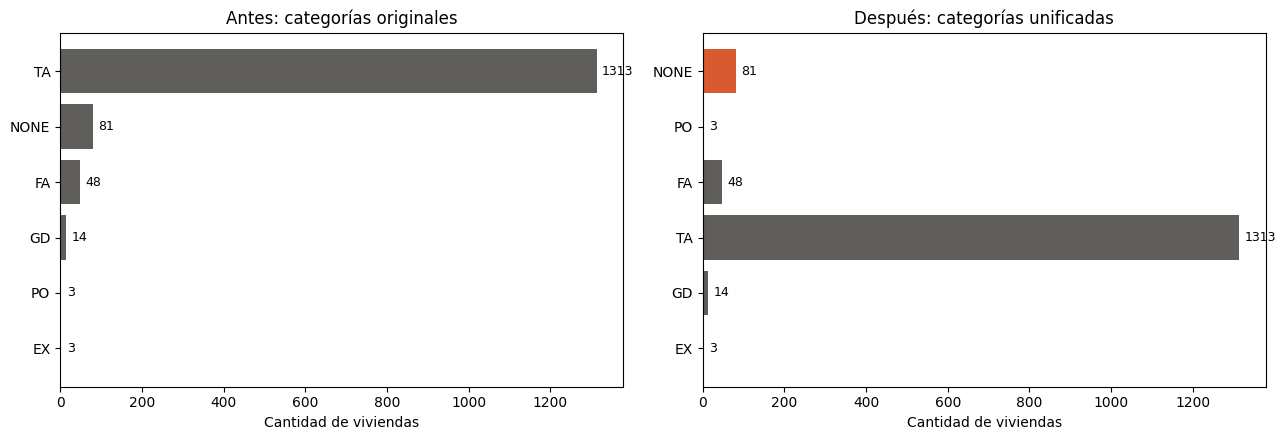

In [ ]:
# GarageQual

df_antes = df['GarageQual'].copy()

print('Frecuencias originales:')
print(df['GarageQual'].value_counts(dropna=False))

# Se puede observar que hay una falsa categoría: NaN y NA probablemente
# hagan referencia a la ausencia de garage.

# Estrategia adoptada: pasamos todo a mayúsculas y unificamos
# las distintas representaciones de ausencia bajo una única categoría.

df['GarageQual'] = df['GarageQual'].str.strip().str.upper()

# Unificamos NA y NaN bajo la categoría NONE
df['GarageQual'] = df['GarageQual'].fillna('NONE')
df['GarageQual'] = df['GarageQual'].replace('NA', 'NONE')

print('\nFrecuencias después de unificar los nulos:')
print(df['GarageQual'].value_counts(dropna=False))

graficar_antes_despues_categorias(
    antes_crudo=df_antes,
    despues=df['GarageQual'],
    orden_final=['NONE', 'PO', 'FA', 'TA', 'GD', 'EX'],
    categoria_nueva='NONE',
    categorias_fusionadas=('NA', 'NAN')
)

##Seccion 1.3

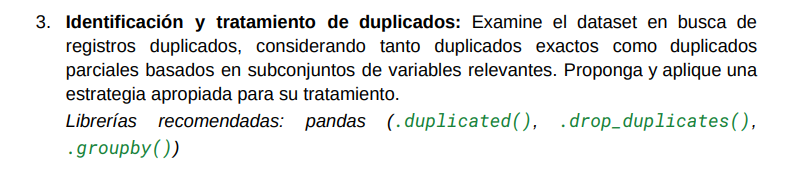

In [ ]:
#Evaluamos cuantos registros estan duplicados

cant_filas_duplicadas = df.duplicated().sum()
print(f'Cantidad de filas duplicadas: {cant_filas_duplicadas}')
# Filtrar el DataFrame para conservar todas las filas duplicadas


duplicados = df[df.duplicated(keep=False)]
frecuencia_duplicados = (
    duplicados
    .groupby(list(df.columns), dropna=False)
    .size()
    .sort_values(ascending=False)
)

frecuencia_duplicados


len(duplicados)
#frecuencia_duplicados['frecuencia'].value_counts()

Cantidad de filas duplicadas: 0


0

In [ ]:
duplicados_ordenados = duplicados.sort_values(
    by=list(df.columns)
)

duplicados_ordenados

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence


Como primer paso, se verificó la existencia de registros duplicados mediante df.duplicated(). Este método identificó 25 apariciones duplicadas respecto de una primera aparición, es decir, 25 filas que repiten exactamente los valores de una fila ubicada anteriormente en el DataFrame. Luego, al utilizar keep=False, se identificaron 50 observaciones involucradas en duplicaciones. Esto significa que existen 25 pares de filas idénticas, donde cada par está compuesto por una primera aparición y su correspondiente duplicado. Además, se comprobó que todos los grupos de registros duplicados tienen una frecuencia de 2, por lo que ningún registro aparece tres o más veces.


A continuación, se decidió investigar si determinadas variables presentaban coincidencias parciales particularmente relevantes.

La idea no fue simplemente buscar las variables cuyos valores aparecen más veces, sino identificar aquellas que poseen una mayor capacidad discriminativa entre viviendas.

Una variable es más interesante para este análisis cuando sus valores representan características relativamente específicas de una propiedad. Por el contrario, variables con pocos valores posibles, como una escala de calidad o una cantidad reducida de categorías, pueden presentar muchas repeticiones simplemente por su naturaleza.

Por este motivo, se decidió analizar progresivamente diferentes grupos de variables, desde características físicas más específicas hacia características estructurales y contextuales.

In [ ]:
#Variables de cada nivel
variables_nivel_1 = [
    'LotFrontage',
    'LotArea',
    'GarageArea'
]

variables_nivel_2 = [
    'LotFrontage',
    'LotArea',
    'GarageArea',
    'YearBuilt',
    'OverallCond'
]

variables_nivel_3 = [
    'LotFrontage',
    'LotArea',
    'GarageArea',
    'YearBuilt',
    'OverallCond',
    'Neighborhood',
    'SalePrice'
]


#Función para obtener las frecuencias de los grupos duplicados
def obtener_frecuencias(df, variables):
    frecuencias = (df.groupby(variables, dropna=False).size())
    frecuencias = frecuencias[frecuencias > 1]
    return frecuencias.value_counts().sort_index()


#Obtener distribución de frecuencias para cada nivel
freq_nivel_1 = obtener_frecuencias(df, variables_nivel_1)
freq_nivel_2 = obtener_frecuencias(df, variables_nivel_2)
freq_nivel_3 = obtener_frecuencias(df, variables_nivel_3)


#Unir los tres niveles
tabla_frecuencias = pd.concat(
    [freq_nivel_1, freq_nivel_2, freq_nivel_3], axis=1)

tabla_frecuencias.columns = ['Nivel 1', 'Nivel 2', 'Nivel 3']
tabla_frecuencias = tabla_frecuencias.fillna(0)

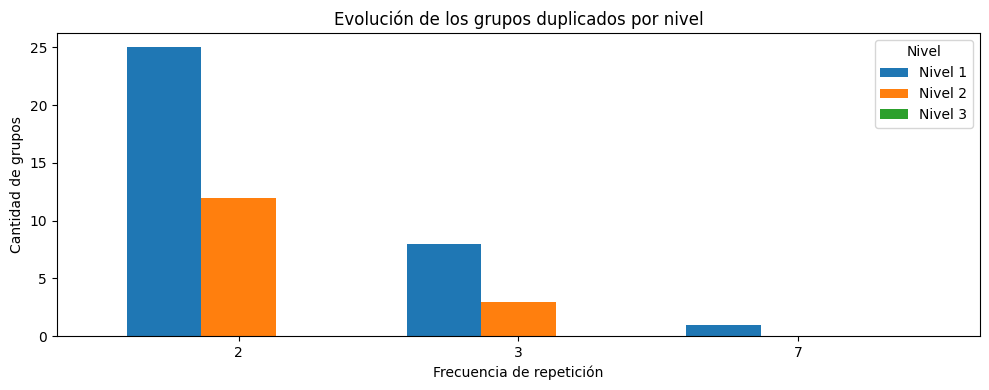

In [ ]:
ax = tabla_frecuencias.plot(
    kind='bar',
    figsize=(10, 4),
    width=0.8
)

plt.xlabel('Frecuencia de repetición')
plt.ylabel('Cantidad de grupos')
plt.title('Evolución de los grupos duplicados por nivel')
plt.xticks(rotation=0)
plt.legend(title='Nivel')

plt.tight_layout()
plt.show()

Nivel 1 — Características físicas:
Al analizar coincidencias utilizando dimensiones físicas concretas de una propiedad, se encontraron grupos con frecuencias de repetición de hasta 8 observaciones. Esto muestra que varias viviendas pueden compartir simultáneamente determinadas características, por lo que una coincidencia parcial no resulta suficiente para considerarlas duplicados.

Nivel 2 — Características estructurales:
Al incorporar información adicional relacionada con las características estructurales de las viviendas, las coincidencias disminuyeron considerablemente. Los grupos de mayor frecuencia desaparecieron y la máxima frecuencia pasó a ser 3. Esto indica que parte de las coincidencias observadas inicialmente podían diferenciarse al considerar información adicional.

Nivel 3 — Contexto y precio:
Finalmente, al incorporar información contextual y el precio de venta, todas las coincidencias restantes quedaron reducidas a pares. Esto evidencia que, a medida que se incorporan variables adicionales, aumenta la capacidad de distinguir entre observaciones que inicialmente parecían duplicadas.

Si bien se identificaron 50 observaciones involucradas en duplicaciones, correspondientes a 25 pares de registros idénticos, no es posible afirmar con total certeza que se trate de duplicados reales debido a que no se dispone del dataset completo ni de información adicional que permita verificar si estas viviendas representan efectivamente observaciones repetidas. Sin embargo, considerando las características del dataset analizado y los resultados obtenidos, se opta por eliminar estos registros duplicados, ya que mantenerlos podría otorgar un peso mayor a determinadas observaciones y afectar el análisis posterior.


In [ ]:
print("Tamaño del dataset antes de eliminar duplicados:" ,{df.shape})

df = df.drop_duplicates()

print("Tamaño del dataset después de eliminar duplicados:", {df.shape})
# Habia 25 duplicados exactos por lo que nos deberian quedar 25 datos  menos

Tamaño del dataset antes de eliminar duplicados: {(1462, 14)}
Tamaño del dataset después de eliminar duplicados: {(1462, 14)}


#Ejercicio 2

##Seccion 2.1


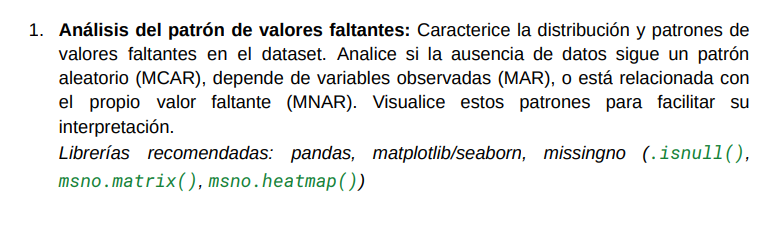

Primero comprobamos los valores faltantes

,Tipo de Dato,Datos Válidos (No Nulos),Datos Faltantes (Nulos),% de Faltantes
PoolQC,object,7,1455,99.52
Fence,object,282,1180,80.71
LotFrontage,float64,1202,260,17.78
GarageQual,object,1381,81,5.54
MSZoning,object,1462,0,0.00
SalePrice,int64,1462,0,0.00
OverallCond,int64,1462,0,0.00
LotArea,int64,1462,0,0.00
Neighborhood,object,1462,0,0.00
YearBuilt,int64,1462,0,0.00


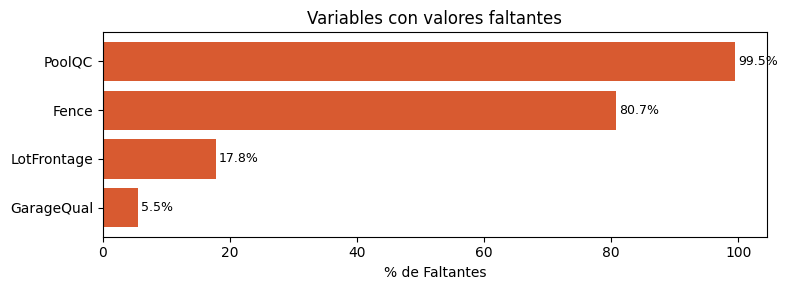

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NONE,NONE
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NONE,NONE
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NONE,NONE
3,307000,RL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NONE,NONE
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NONE,NONE


In [ ]:
resumen = armar_resumen(df)

display(resumen)
graficar_faltantes(resumen, umbral=0)
df.head()


Vemos que la mayoría de las características están completas a excepción de 4, por lo que analizaremos el motivo de la ausencia de datos para estas 4 categorías (MCAR, MNAR, MAR):

Analicemos primero PoolQC. Tiene sentido que todas las casas sin pileta no tengan un valor para esta característica, ya que no se puede calificar una pileta que no existe. Para comprobar si nuestra hipótesis es correcta, visualizamos todas las filas que tengan valores nulos de esta categoría en conjunto con los metros cuadrados de las piletas de dichas casas; si el valor es 0, ¡bingo!, tenemos una MNAR.

In [ ]:
#PoolQC
df_antes = df.copy()
#cambiamos los valoress de piletas sin completar a NONE
df['PoolQC'] = df['PoolQC'].fillna('NONE')
print('\n')
# AHORA filtramos estas filas y escribimos su area de pileta , si realmente la casa no cuenta con pileta , el area deberia ser cero
filas_sin_pileta = df[(df['PoolQC'].isna()) | (df['PoolQC'] == 'NONE')]

display(filas_sin_pileta[['PoolQC', 'PoolArea']])
df['PoolQC'].value_counts(dropna=False)


,PoolQC,PoolArea
0,NONE,0
1,NONE,0
2,NONE,0
3,NONE,0
4,NONE,0
...,...,...
1482,NONE,0
1483,NONE,0
1484,NONE,0
1485,NONE,0


,count
PoolQC,
NONE,1455
Gd,3
Ex,2
Fa,2


Ahora imprimimos todos los valores nulos de 'fence':



In [ ]:
#Fence

df['Fence'].value_counts(dropna = False)

filas_fence_nan = df[df['Fence'] == 'NONE']

# Muestra todas las filas resultantes en el notebook
display(filas_fence_nan)


,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NONE,NONE
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NONE,NONE
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NONE,NONE
3,307000,RL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NONE,NONE
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NONE,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,155000,FV,Somerst,24.0,2572,5,1999,2,3,TA,484,0,NONE,NONE
1482,270000,RL,Timber,85.0,14536,5,2002,2,3,TA,808,0,NONE,NONE
1483,109008,RL,NAmes,77.0,8593,6,1957,1,3,TA,352,0,NONE,NONE
1484,102000,RL,Edwards,67.0,8877,5,1951,1,2,TA,396,0,NONE,NONE


Analizando la descripcion del dataset y explorando la ciudad de Ames por google maps, podemos llegar a la conclusión de que los NaN son, efectivamente las casas que no cuentan con cerco. nos encontramos ante un UN caso de MNAR


Ahora pasamos a GarageQual donde sucede lo mismo que con PoolQC verificamos que la falta de datos sea , justamente , por falta de garage , si es asi, simplemente remplazamos por NONE (none existen)

In [ ]:
# GarageQual

# Verificamos si los NONE son realmente faltantes
# o si indican que no existe garage.

display(
    df.loc[df['GarageQual'] == 'NONE', 'GarageArea'].value_counts()
)

# Comprobamos que todos los NONE corresponden a viviendas sin garage.

sin_garage = df['GarageArea'] == 0

assert (df.loc[df['GarageQual'] == 'NONE', 'GarageArea'] == 0).all(), \
    "Existen NONE en GarageQual asociados a una GarageArea distinta de 0"

print('Todos los NONE de GarageQual corresponden a viviendas sin garage.')

,count
GarageArea,
0,81


Todos los NONE de GarageQual corresponden a viviendas sin garage.


Por ultimo , nos queda verificar la razon de los valores nulos de Lot frontage:

In [ ]:
# Filtramos el dataframe para quedarnos solo con los LotFrontage nulos
nulos_lotfrontage = df[df['LotFrontage'].isna()]

print("\n--- Dataset completo de las casas sin LotFrontage ---")
display(nulos_lotfrontage)


--- Dataset completo de las casas sin LotFrontage ---


,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NONE,NONE
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NONE,NONE
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NONE,NONE
7,112000,RL,Mitchel,NaN,8780,5,1985,1,3,NONE,0,0,NONE,MnPrv
13,157900,RL,Mitchel,NaN,26142,7,1962,1,3,TA,312,0,NONE,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1437,222000,RL,Crawfor,NaN,21695,9,1988,2,3,TA,540,0,NONE,NONE
1441,163500,RL,NAmes,NaN,12155,3,1970,2,3,TA,484,0,NONE,NONE
1446,302000,RL,ClearCr,NaN,115149,5,1971,2,2,TA,739,0,NONE,NONE
1455,244400,RL,ClearCr,NaN,24090,7,1940,2,4,TA,349,0,NONE,NONE


In [ ]:
# Filtramos las propiedades donde LotFrontage es nulo
nulos_df = df[df['LotFrontage'].isna()]

tabla_zona = (
    nulos_df['MSZoning']
    .value_counts()
    .reset_index()
)
tabla_zona.columns = ['Tipo de Zona (MSZoning)', 'Cantidad de Nulos']

print("--- Nulos de LotFrontage por Tipo de Zona ---")
display(tabla_zona)

tabla_barrio = (
    nulos_df['Neighborhood']
    .value_counts()
    .reset_index()
)
tabla_barrio.columns = ['Barrio (Neighborhood)', 'Cantidad de Nulos']

print("\n--- Nulos de LotFrontage por Barrio ---")
display(tabla_barrio)

--- Nulos de LotFrontage por Tipo de Zona ---


,Tipo de Zona (MSZoning),Cantidad de Nulos
0,RL,229
1,RM,20
2,FV,8
3,RH,3



--- Nulos de LotFrontage por Barrio ---


,Barrio (Neighborhood),Cantidad de Nulos
0,NAmes,39
1,Gilbert,30
2,NWAmes,28
3,Sawyer,26
4,CollgCr,25
5,ClearCr,15
6,Mitchel,13
7,Crawfor,10
8,SawyerW,9
9,Edwards,8


Bingo! Los valores nulos coinciden casi en su totalidad con las cas en la zona RL! es un mnar... o no?

Para verifivar esto, vamos a hcer un poco de EDA Y verificar las proporciones:

In [ ]:
import pandas as pd

# Filtro booleano de nulos en LotFrontage
es_nulo = df['LotFrontage'].isna()

total_zona = df['MSZoning'].value_counts()
nulos_zona = df[es_nulo]['MSZoning'].value_counts()

tabla_zona = pd.DataFrame({
    'Total Casos': total_zona,
    'Cantidad Nulos': nulos_zona,
    'Porcentaje Nulos (%)': (nulos_zona / total_zona) * 100
}).fillna({'Cantidad Nulos': 0, 'Porcentaje Nulos (%)': 0})

tabla_zona['Cantidad Nulos'] = tabla_zona['Cantidad Nulos'].astype(int)
tabla_zona = tabla_zona.sort_values(by='Porcentaje Nulos (%)', ascending=False)

print("--- Nulos de LotFrontage por Tipo de Zona (MSZoning) ---")
display(
    tabla_zona.style
    .format({'Porcentaje Nulos (%)': "{:.2f}%"})
    .background_gradient(subset=['Porcentaje Nulos (%)'], cmap='Reds')
)
total_barrio = df['Neighborhood'].value_counts()
nulos_barrio = df[es_nulo]['Neighborhood'].value_counts()

tabla_barrio = pd.DataFrame({
    'Total Casos': total_barrio,
    'Cantidad Nulos': nulos_barrio,
    'Porcentaje Nulos (%)': (nulos_barrio / total_barrio) * 100
}).fillna({'Cantidad Nulos': 0, 'Porcentaje Nulos (%)': 0})

tabla_barrio['Cantidad Nulos'] = tabla_barrio['Cantidad Nulos'].astype(int)
tabla_barrio = tabla_barrio.sort_values(by='Porcentaje Nulos (%)', ascending=False)

print("\n--- Nulos de LotFrontage por Barrio (Neighborhood) ---")
display(
    tabla_barrio.style
    .format({'Porcentaje Nulos (%)': "{:.2f}%"})
    .background_gradient(subset=['Porcentaje Nulos (%)'], cmap='Reds')
)

--- Nulos de LotFrontage por Tipo de Zona (MSZoning) ---


,Total Casos,Cantidad Nulos,Porcentaje Nulos (%)
MSZoning,,,
RL,1153,229,19.86%
RH,16,3,18.75%
FV,65,8,12.31%
RM,218,20,9.17%
C (ALL),10,0,0.00%



--- Nulos de LotFrontage por Barrio (Neighborhood) ---


,Total Casos,Cantidad Nulos,Porcentaje Nulos (%)
Neighborhood,,,
ClearCr,28,15,53.57%
Gilbert,79,30,37.97%
NWAmes,74,28,37.84%
Veenker,11,4,36.36%
Sawyer,74,26,35.14%
Mitchel,49,13,26.53%
NPkVill,9,2,22.22%
Timber,38,8,21.05%
StoneBr,25,5,20.00%


Viendo los datos podemos llegar a la conclusion de que los datos parecieran tener una tendecia a tener más o menos registros  de LotFrontage por lo que pareciera tratarse de un MAR que nos puede servir como un dato más a la hora de entrenar nuestro modelo. Y los datos nulos quedan fianlemnte asi:

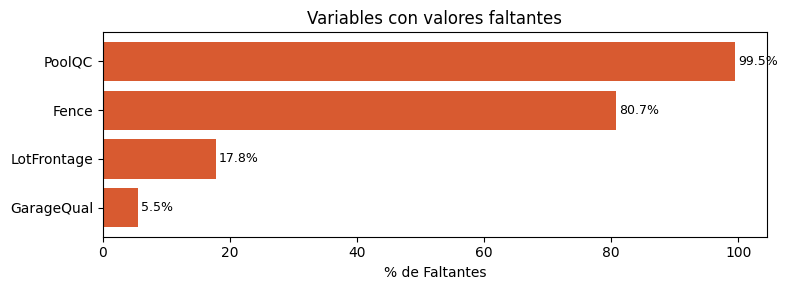

In [ ]:


resumen = armar_resumen(df)

graficar_faltantes(resumen, umbral=0)


Hasta esta sección, hemos aplicado correcciones lógicas y de formato (errores de tipeo, estandarización de categorías y tratamiento de nulos estructurales o MNAR) que no alteran la distribución estadística de los datos. A partir de los siguientes ejercicios, comenzaremos a aplicar transformaciones que dependen del estado de los datos ('stateful transformations', como imputación estadística y manejo de outliers). Por lo tanto, para evitar la Fuga de Datos (Data Leakage), guardaremos el estado actual de nuestro dataset limpio. Este será el punto de partida que utilizaremos en el Ejercicio 6, donde lo dividiremos en conjuntos de entrenamiento y prueba antes de aplicar cualquier transformación dentro de un Pipeline.

In [ ]:
df_pipeline=df.copy()

##Seccion 2.2

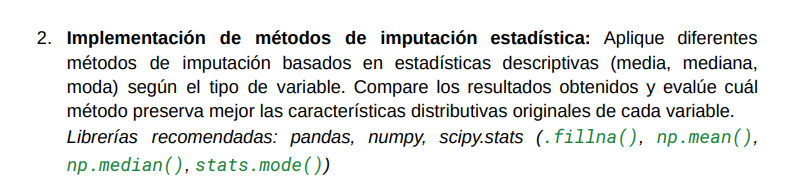

In [ ]:
display(armar_resumen(df))
col_numericas = df.select_dtypes(include=[np.number]).columns
missing_numerico = resumen.loc[resumen.index.isin(col_numericas) & (resumen['% de Faltantes'] > 0)]
display(missing_numerico)

,Tipo de Dato,Datos Válidos (No Nulos),Datos Faltantes (Nulos),% de Faltantes
PoolQC,object,7,1455,99.52
Fence,object,282,1180,80.71
LotFrontage,float64,1202,260,17.78
GarageQual,object,1381,81,5.54
MSZoning,object,1462,0,0.00
SalePrice,int64,1462,0,0.00
OverallCond,int64,1462,0,0.00
LotArea,int64,1462,0,0.00
Neighborhood,object,1462,0,0.00
YearBuilt,int64,1462,0,0.00


,Tipo de Dato,Datos Válidos (No Nulos),Datos Faltantes (Nulos),% de Faltantes
LotFrontage,float64,1202,260,17.78


In [ ]:
skewness_lotfrontage = df['LotFrontage'].skew()
print(f"Asimetría de LotFrontage: {skewness_lotfrontage:.3f}")

Asimetría de LotFrontage: 2.170


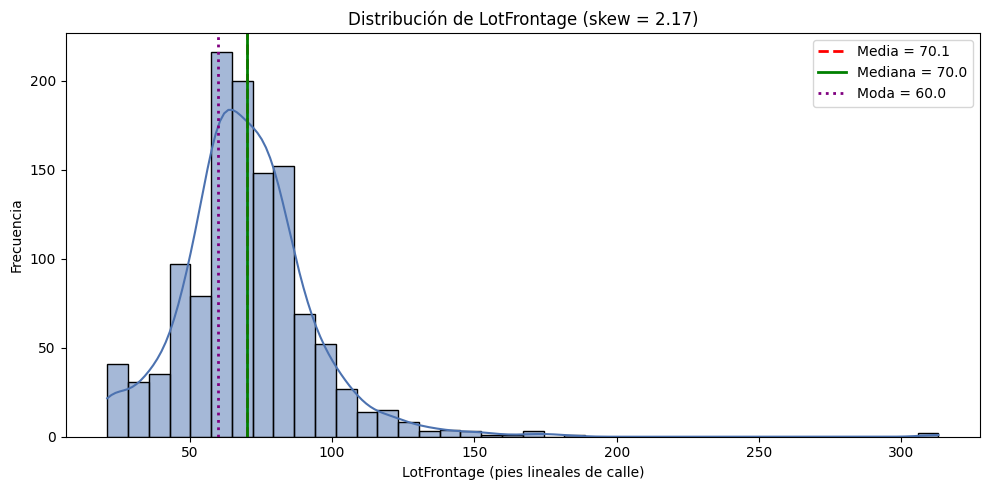

In [ ]:
# Histograma + KDE de LotFrontage, con líneas de media/mediana superpuestas
# para que se vea a simple vista cómo la cola derecha "arrastra" la media
# lejos del centro de masa real de los datos (por eso conviene mediana)
datos_lotfrontage = df['LotFrontage'].dropna()
media = datos_lotfrontage.mean()
mediana = datos_lotfrontage.median()
moda = datos_lotfrontage.mode()[0]

plt.figure(figsize=(10, 5))
sns.histplot(datos_lotfrontage, kde=True, color='#4C72B0', bins=40)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana = {mediana:.1f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda = {moda:.1f}')
plt.title(f'Distribución de LotFrontage (skew = {skewness_lotfrontage:.2f})')
plt.xlabel('LotFrontage (pies lineales de calle)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

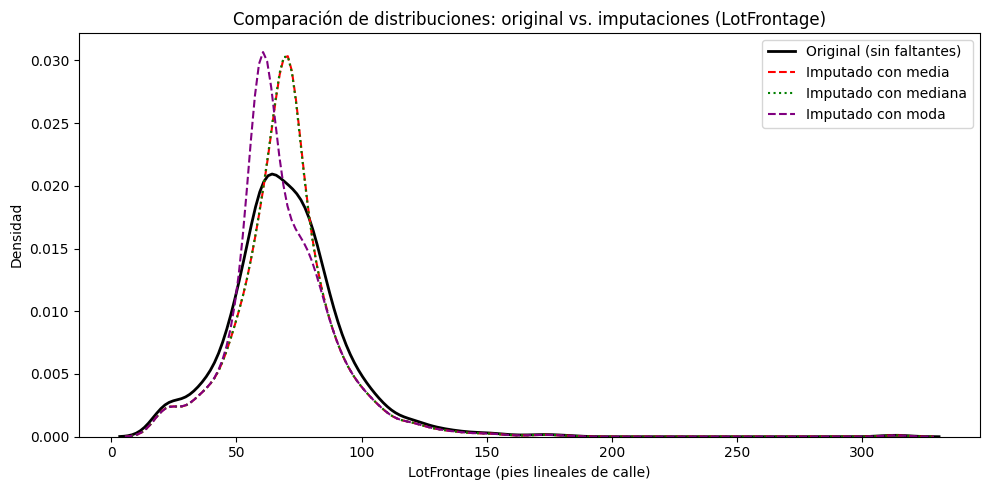

In [ ]:
# Cada imputación se calcula sobre una copia de la serie original (fillna
# no es in-place acá) para poder superponerlas sin pisar df ni entre sí
serie_original = df['LotFrontage']
imputado_media = serie_original.fillna(media)
imputado_mediana = serie_original.fillna(mediana)
imputado_moda = serie_original.fillna(moda)

plt.figure(figsize=(10, 5))
sns.kdeplot(datos_lotfrontage, label='Original (sin faltantes)', color='black', linewidth=2)
sns.kdeplot(imputado_media, label='Imputado con media', color='red', linestyle='--')
sns.kdeplot(imputado_mediana, label='Imputado con mediana', color='green', linestyle=':')
sns.kdeplot(imputado_moda, label='Imputado con moda', color='purple', linestyle='--')
plt.title('Comparación de distribuciones: original vs. imputaciones (LotFrontage)')
plt.xlabel('LotFrontage (pies lineales de calle)')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()


Este fenómeno ocurre porque la imputación univariada simple reemplaza todos los valores faltantes por un único valor escalar constante, lo que infla artificialmente la densidad de probabilidad en ese punto exacto, reduce la varianza natural de la variable y distorsiona la forma original de la distribución al superponer la media con la mediana por su cercanía numérica o al desplazar el pico hacia la izquierda en el caso de la moda

##Seccion 2.3

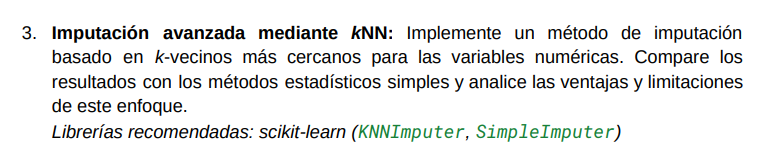

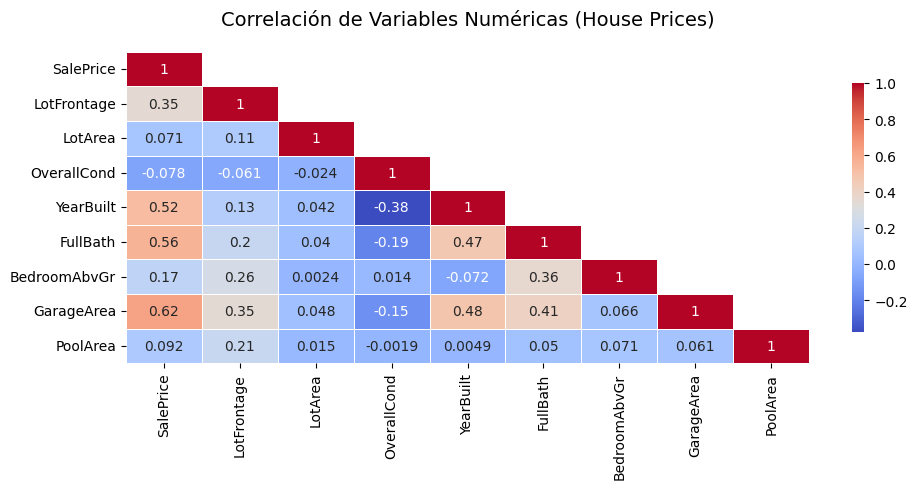

In [ ]:
#Primero hacemos un heatmap para indicar las variables mas correlacionadas con la de interes para que el knn
#pueda usarlas para imputar correctamente

df_numerico = df.select_dtypes(include=[np.number])
correlacion = df_numerico.corr()

#Generar una máscara booleana para el triángulo superior (incluye la diagonal)
mascara = np.triu(np.ones_like(correlacion, dtype=bool), k = 1)

plt.figure(figsize=(10, 5))

sns.heatmap(
    correlacion,
    mask=mascara,
    cmap='coolwarm',       # Escala divergente: rojo (positiva), azul (negativa)
    annot=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlación de Variables Numéricas (House Prices)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


De esta manera, seleccionamos GarageArea, BedroomAbvGr y PoolArea

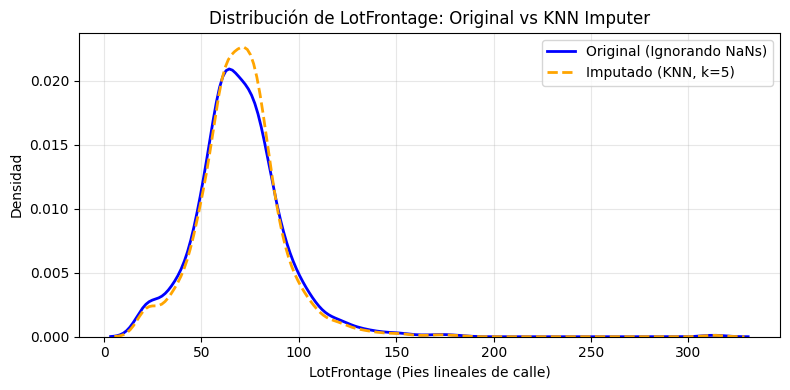

In [ ]:
#Imputacion por KNN para la variable LotFrontage

columnas_knn = ['LotFrontage', 'GarageArea', 'PoolArea', 'BedroomAbvGr']
df_knn = df[columnas_knn].copy()

#Aplicamos KNNImputer
imputador_knn = KNNImputer(n_neighbors=5) #usamos la cantidad estandar de la funcion
df_imputado_array = imputador_knn.fit_transform(df_knn)

#Reconstruimos un DataFrame temporal con los datos imputados para graficar
df_imputado = pd.DataFrame(df_imputado_array, columns=columnas_knn)

#Gráfico de densidad superpuesto (KDE)
plt.figure(figsize=(8, 4))

#Distribución original ignorando los valores nulos (dropna)
sns.kdeplot(df['LotFrontage'].dropna(),
            label='Original (Ignorando NaNs)',
            color='blue',
            linewidth=2)

#Distribución con los valores imputados por KNN
sns.kdeplot(df_imputado['LotFrontage'],
            label='Imputado (KNN, k=5)',
            color='orange',
            linestyle='--',
            linewidth=2)

plt.title('Distribución de LotFrontage: Original vs KNN Imputer')
plt.xlabel('LotFrontage (Pies lineales de calle)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La imputación mediante métodos estadísticos simples, como la media, mediana o moda, tiende a generar distribuciones con picos pronunciados, alejándose de la distribución original de los datos. Esto ocurre porque todos los valores faltantes son reemplazados por un mismo valor representativo. En cambio, KNN utiliza los valores de observaciones similares para realizar la imputación, generando valores más variados y acordes con la estructura de los datos, por lo que la distribución resultante se aproxima más a la original.


#Ejercicio 3

##Seccion 3.1

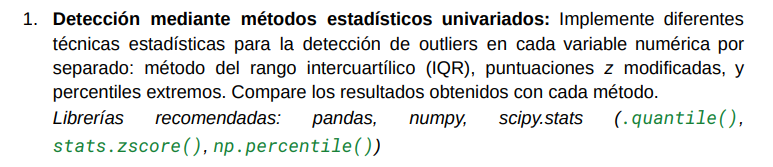

SalePrice

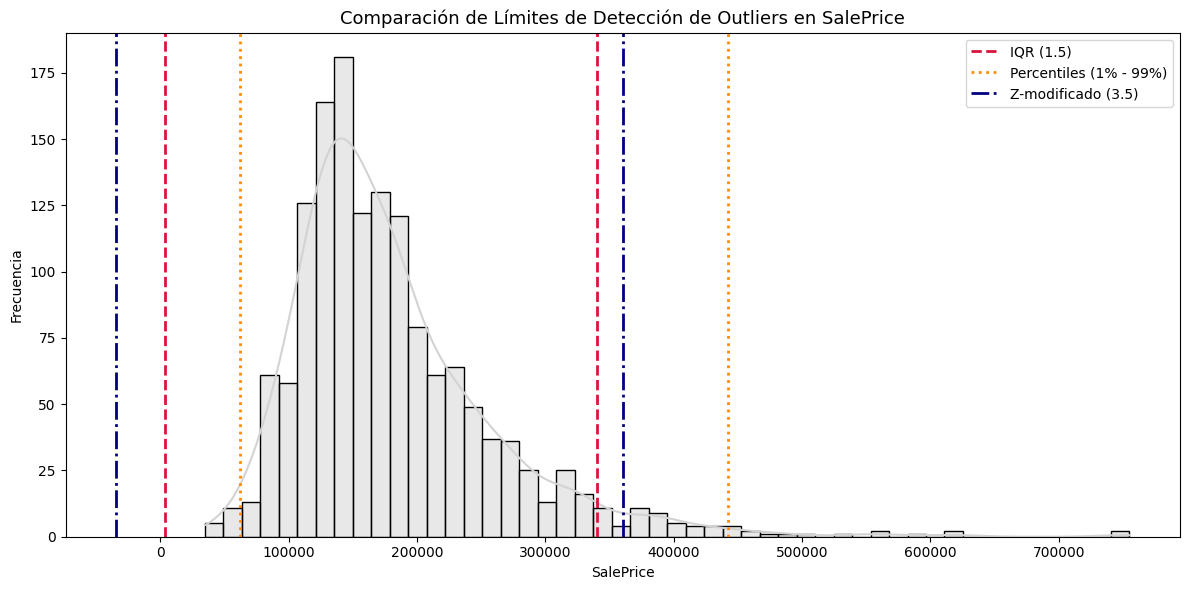

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['SalePrice'].quantile(0.25)
q3 = df['SalePrice'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['SalePrice'].quantile(0.01)
p_sup = df['SalePrice'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['SalePrice'].median()
mad = stats.median_abs_deviation(df['SalePrice'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['SalePrice'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en SalePrice', fontsize=13)
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

LotFrontage

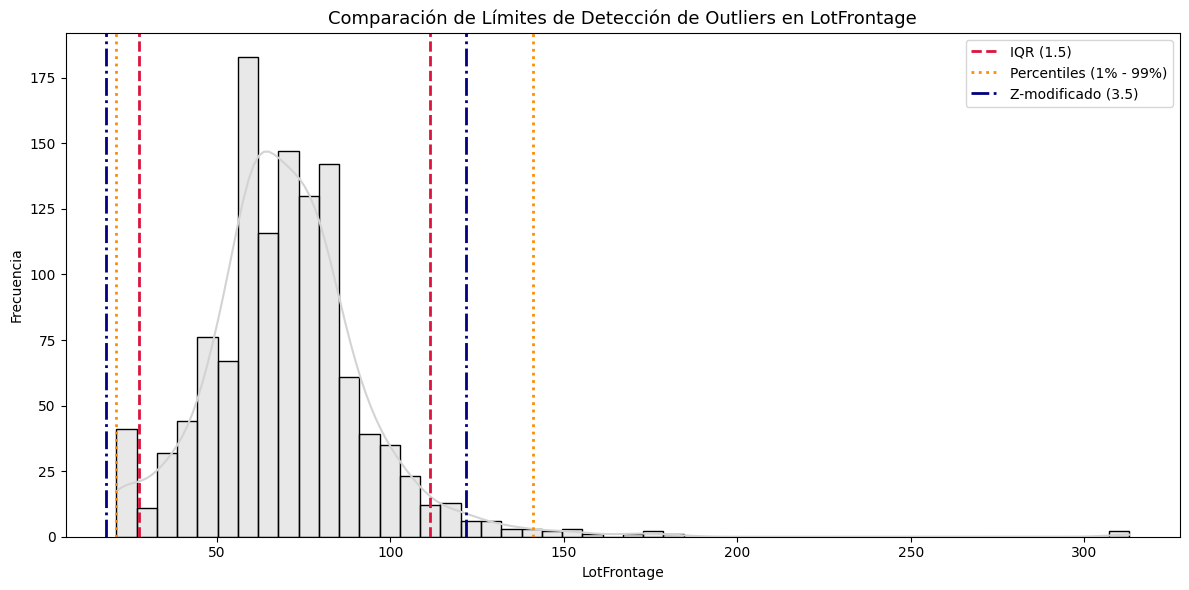

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['LotFrontage'].quantile(0.25)
q3 = df['LotFrontage'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['LotFrontage'].quantile(0.01)
p_sup = df['LotFrontage'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['LotFrontage'].median()
mad = stats.median_abs_deviation(df['LotFrontage'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['LotFrontage'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en LotFrontage', fontsize=13)
plt.xlabel('LotFrontage')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

LotArea

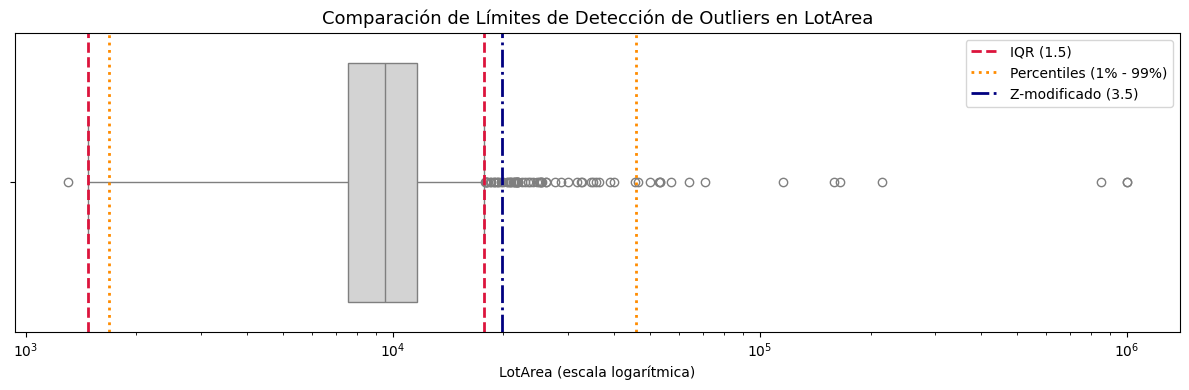

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['LotArea'].quantile(0.25)
q3 = df['LotArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['LotArea'].quantile(0.01)
p_sup = df['LotArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['LotArea'].median()
mad = stats.median_abs_deviation(df['LotArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico

plt.figure(figsize=(12, 4))

sns.boxplot(x=df['LotArea'], color='lightgray')

plt.xscale('log')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en LotArea', fontsize=13)

plt.xlabel('LotArea (escala logarítmica)')

plt.legend()

plt.tight_layout()

plt.show()

YearBuilt

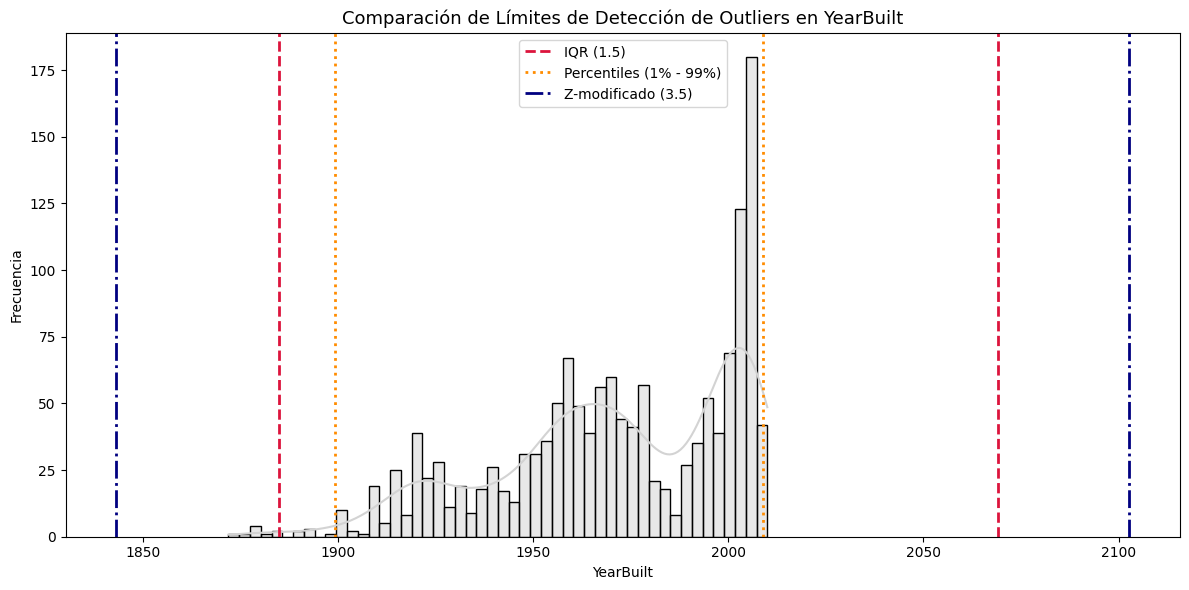

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['YearBuilt'].quantile(0.25)
q3 = df['YearBuilt'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['YearBuilt'].quantile(0.01)
p_sup = df['YearBuilt'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['YearBuilt'].median()
mad = stats.median_abs_deviation(df['YearBuilt'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['YearBuilt'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en YearBuilt', fontsize=13)
plt.xlabel('YearBuilt')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

FullBath



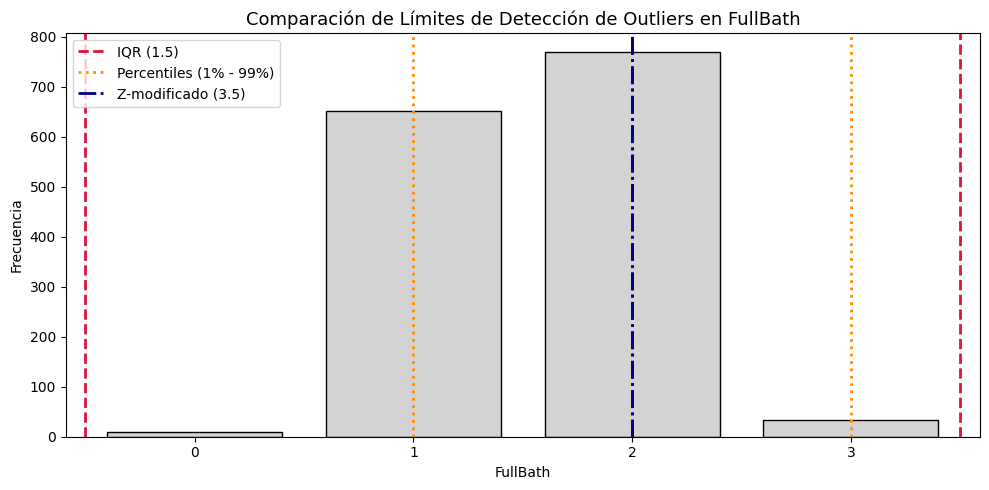

In [ ]:
#Cálculo de umbrales

#IQR

q1 = df['FullBath'].quantile(0.25)

q3 = df['FullBath'].quantile(0.75)

iqr = q3 - q1

iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99

p_inf = df['FullBath'].quantile(0.01)

p_sup = df['FullBath'].quantile(0.99)

#Z-score modificado (umbral = 3.5)

mediana = df['FullBath'].median()

mad = stats.median_abs_deviation(df['FullBath'].dropna())

zmod_inf = mediana - (3.5 * mad) / 0.6745

zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico

plt.figure(figsize=(10, 5))

frecuencias = df['FullBath'].value_counts().sort_index()

plt.bar(
    frecuencias.index,
    frecuencias.values,
    color='lightgray',
    edgecolor='black'
)

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')

plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')

plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)

plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)

plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en FullBath', fontsize=13)

plt.xlabel('FullBath')

plt.ylabel('Frecuencia')

plt.xticks(frecuencias.index)

plt.legend()

plt.tight_layout()

plt.show()

BedroomAbvGr

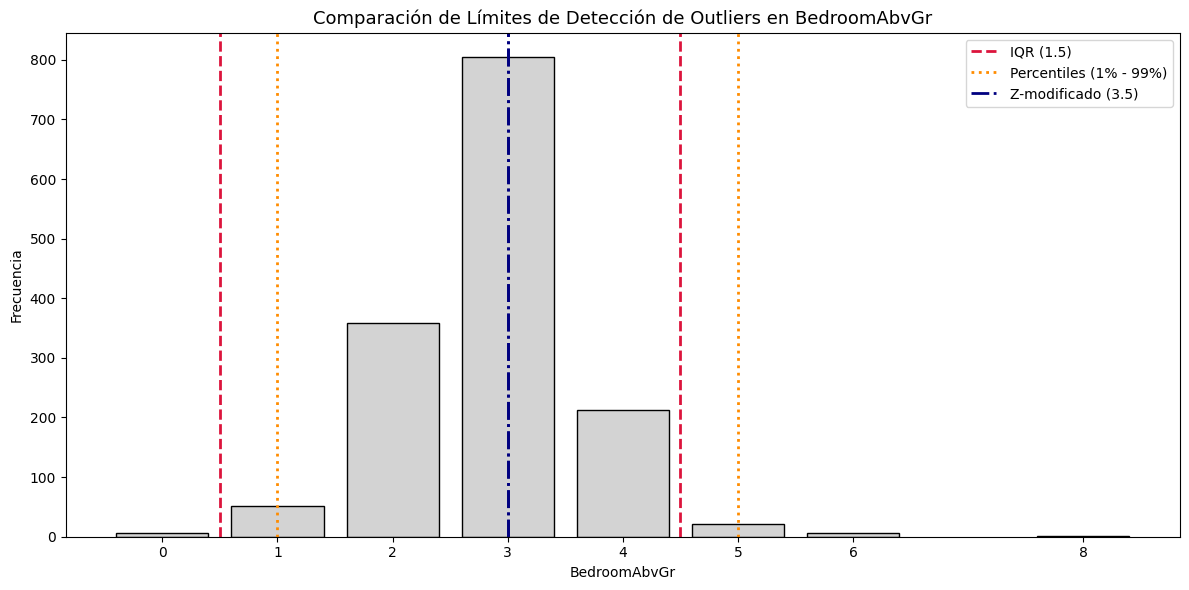

In [ ]:
#Cálculo de umbrales

#IQR

q1 = df['BedroomAbvGr'].quantile(0.25)

q3 = df['BedroomAbvGr'].quantile(0.75)

iqr = q3 - q1

iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99

p_inf = df['BedroomAbvGr'].quantile(0.01)

p_sup = df['BedroomAbvGr'].quantile(0.99)

#Z-score modificado (umbral = 3.5)

mediana = df['BedroomAbvGr'].median()

mad = stats.median_abs_deviation(df['BedroomAbvGr'].dropna())

zmod_inf = mediana - (3.5 * mad) / 0.6745

zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico

plt.figure(figsize=(12, 6))

frecuencias = df['BedroomAbvGr'].value_counts().sort_index()

plt.bar(
    frecuencias.index,
    frecuencias.values,
    color='lightgray',
    edgecolor='black'
)

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')

plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')

plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)

plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)

plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en BedroomAbvGr', fontsize=13)

plt.xlabel('BedroomAbvGr')

plt.ylabel('Frecuencia')

plt.xticks(frecuencias.index)

plt.legend()

plt.tight_layout()

plt.show()

GarageArea

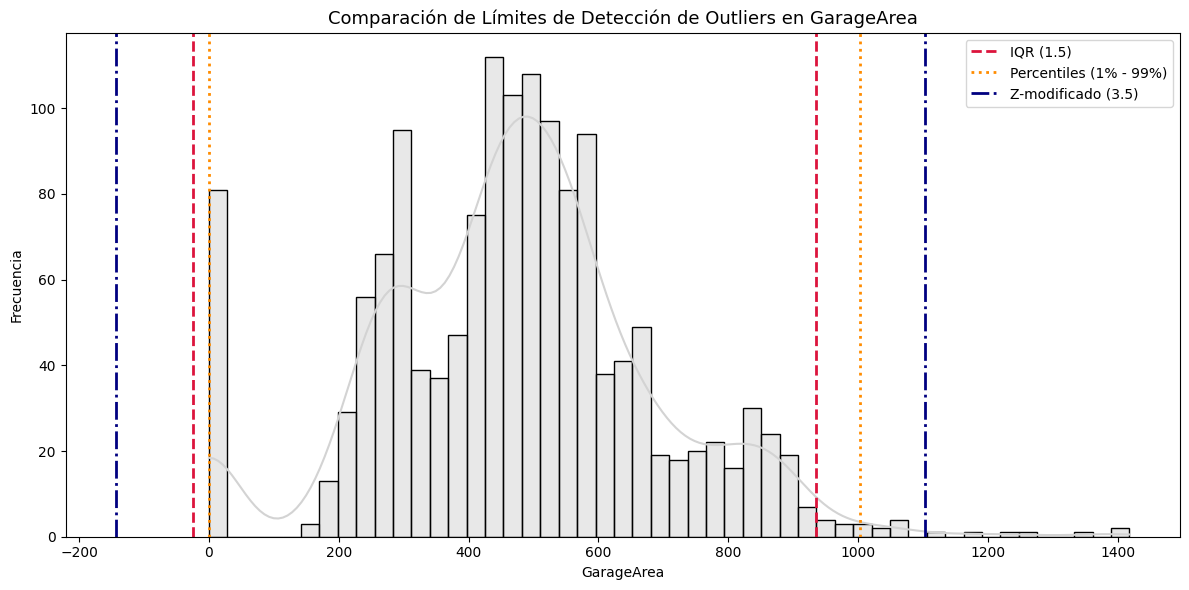

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['GarageArea'].quantile(0.25)
q3 = df['GarageArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['GarageArea'].quantile(0.01)
p_sup = df['GarageArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['GarageArea'].median()
mad = stats.median_abs_deviation(df['GarageArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['GarageArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en GarageArea', fontsize=13)
plt.xlabel('GarageArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

PoolArea

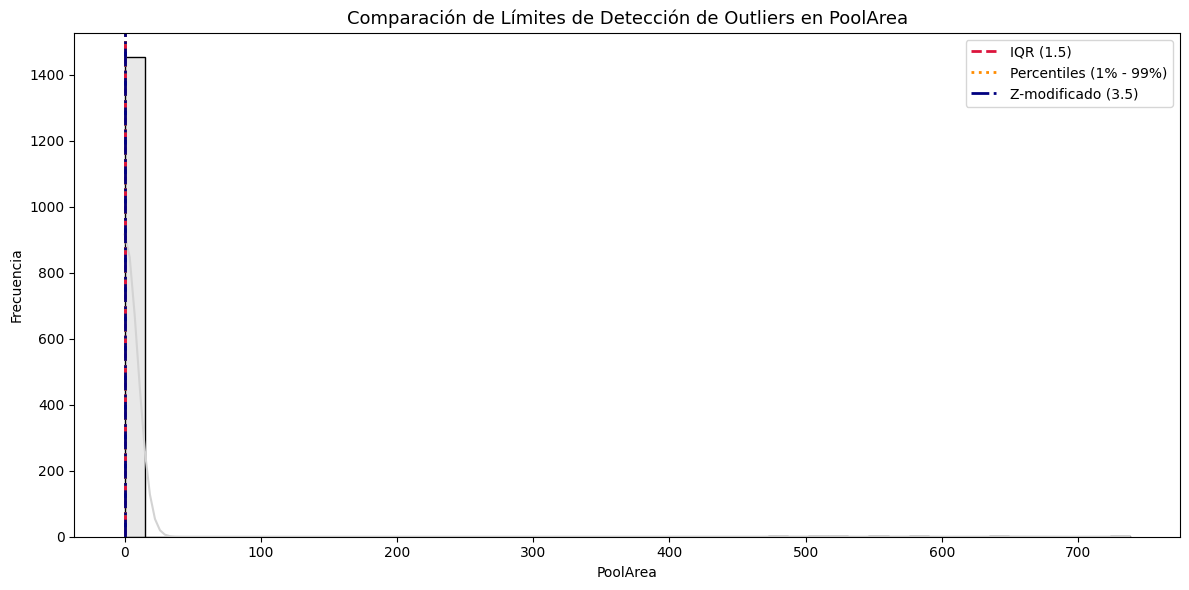

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['PoolArea'].quantile(0.25)
q3 = df['PoolArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['PoolArea'].quantile(0.01)
p_sup = df['PoolArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['PoolArea'].median()
mad = stats.median_abs_deviation(df['PoolArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['PoolArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en PoolArea', fontsize=13)
plt.xlabel('PoolArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

Alternativa (Variables juntas en un solo grafico)

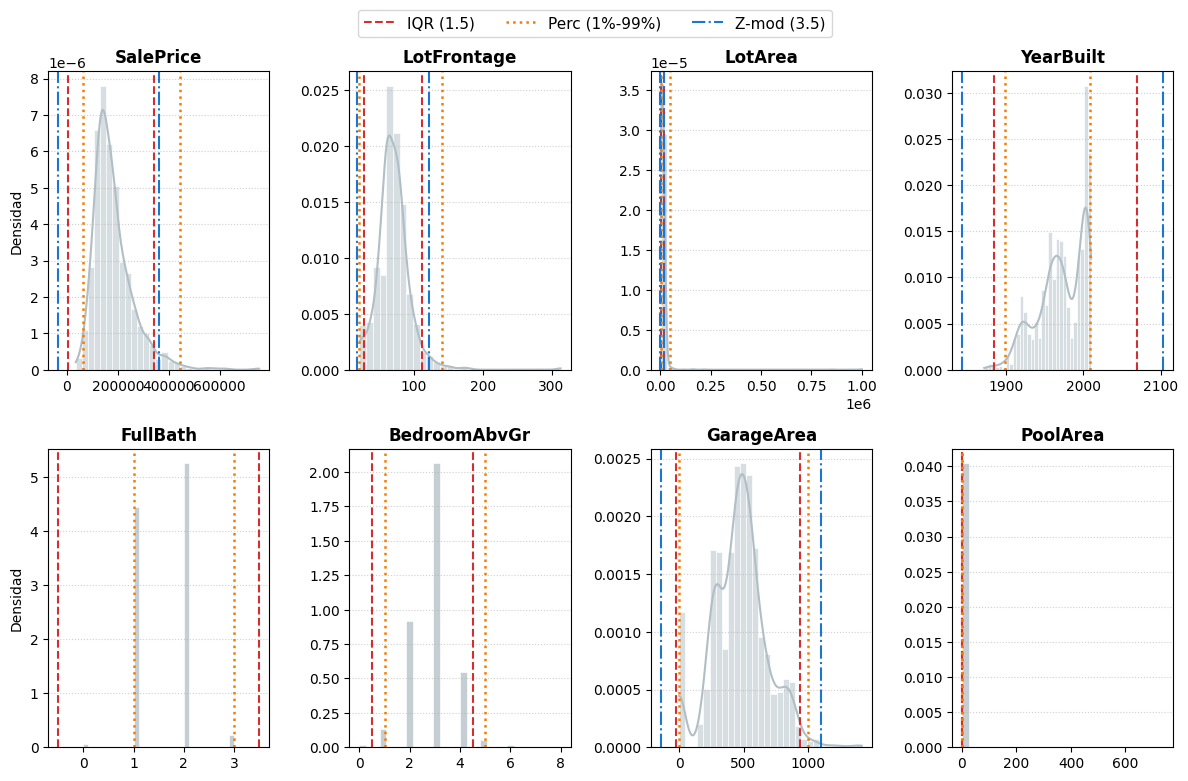

In [ ]:
#Lista de variables a analizar
variables = [
    'SalePrice', 'LotFrontage', 'LotArea', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'GarageArea', 'PoolArea'
]

#Configuración del lienzo: 2 filas x 4 columnas
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(variables):
    ax = axes[i]

    serie = df[col].dropna()

    #Método IQR (1.5 * IQR)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    #Método Percentiles (1% y 99%)
    p_inf = serie.quantile(0.01)
    p_sup = serie.quantile(0.99)

    #Método Z-score Modificado (corte = 3.5)
    mediana = serie.median()
    mad = stats.median_abs_deviation(serie)

    #Control para distribuciones con MAD = 0 (ej. variables discretas o con muchos ceros como PoolArea)
    if mad != 0:
        zmod_inf = mediana - (3.5 * mad) / 0.6745
        zmod_sup = mediana + (3.5 * mad) / 0.6745
    else:
        zmod_inf, zmod_sup = np.nan, np.nan

    #Histograma y curva de densidad (KDE adaptativo si hay suficiente varianza)
    use_kde = True if serie.nunique() > 10 else False
    sns.histplot(serie, ax=ax, kde=use_kde, color='#B0BEC5', stat='density', bins=30, edgecolor='white')

    #Trazado de líneas de umbral (IQR: Rojo, Percentiles: Naranja, Z-mod: Azul)
    ax.axvline(iqr_inf, color='#D32F2F', linestyle='--', linewidth=1.5, label='IQR (1.5)')
    ax.axvline(iqr_sup, color='#D32F2F', linestyle='--', linewidth=1.5)

    ax.axvline(p_inf, color='#F57C00', linestyle=':', linewidth=1.8, label='Perc (1%-99%)')
    ax.axvline(p_sup, color='#F57C00', linestyle=':', linewidth=1.8)

    if not np.isnan(zmod_inf):
        ax.axvline(zmod_inf, color='#1976D2', linestyle='-.', linewidth=1.5, label='Z-mod (3.5)')
        ax.axvline(zmod_sup, color='#1976D2', linestyle='-.', linewidth=1.5)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Densidad' if i % 4 == 0 else '')
    ax.grid(axis='y', linestyle=':', alpha=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=True, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

En términos generales, se observó que el método del rango intercuartílico (IQR) tendió a identificar una mayor cantidad de valores atípicos, seguido por la puntuación Z modificada, aunque este comportamiento varió según la distribución de cada variable. Esto se debe a que ambos métodos utilizan medidas robustas como los cuartiles y la mediana para establecer sus límites, por lo que su comportamiento depende de la concentración y dispersión de los datos. En cambio, el método de percentiles establece límites directamente en función de la posición de los datos, por lo que con un criterio de 1 % y 99 % identifica aproximadamente una proporción fija de observaciones como extremas. Las diferencias observadas entre los métodos se vuelven especialmente importantes en variables con distribuciones asimétricas, donde los límites definidos por IQR y Z modificada pueden diferir considerablemente de los establecidos mediante percentiles.


##Secccion 3.2

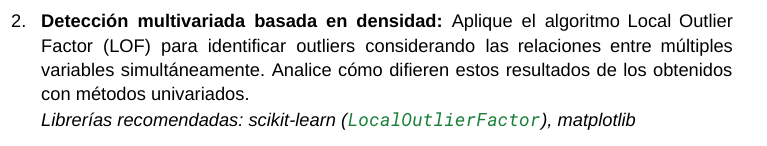

Comparación: outliers univariados (IQR) vs. multivariados (LOF)

Los métodos univariados (IQR) analizan cada variable de forma aislada, por lo que
no detectan un caso "normal" en cada atributo por separado pero atípico en su
combinación. LOF sí captura ese tipo de atípico porque mide
densidad local en el espacio conjunto de las 9 variables. Para cuantificar en qué
medida ambos métodos coinciden o difieren, cruzamos los dos flags binarios en una
tabla de contingencia y aplicamos un test de chi-cuadrado de independencia. La visualización se hace sobre la proyección PCA ya calculada,
usada aquí únicamente para visualizar, no
para detectar outliers. LOF corrió sobre las 9 variables originales
estandarizadas.


In [ ]:
# --- Datos para detección multivariada ---
import numpy as np
import pandas as pd

variables = [
    'LotFrontage',
    'LotArea',
    'OverallCond',
    'YearBuilt',
    'FullBath',
    'BedroomAbvGr',
    'GarageArea',
    'PoolArea',
    'SalePrice'
]

df_lof = df[variables].dropna().copy()

print(f"{len(df_lof)} observaciones en {len(variables)} dimensiones")

1202 observaciones en 9 dimensiones


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

# Escalado de las variables
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_lof[variables])

# --- Detección Multivariada (LOF) ---
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
pred_lof = lof.fit_predict(datos_escalados)
df_lof['outlier_lof'] = pred_lof == -1

In [ ]:
# --- Detección Univariada (IQR) ---

variables = [
    'LotFrontage',
    'LotArea',
    'OverallCond',
    'YearBuilt',
    'FullBath',
    'BedroomAbvGr',
    'GarageArea',
    'PoolArea',
    'SalePrice'
]

df_iqr = df[variables].copy()

outliers_iqr = pd.DataFrame(index=df_iqr.index)

for variable in variables:
    q1 = df_iqr[variable].quantile(0.25)
    q3 = df_iqr[variable].quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_iqr[variable] = (
        (df_iqr[variable] < lim_inf) |
        (df_iqr[variable] > lim_sup)
    )

# Una observación es outlier IQR si lo es en al menos una variable
df_iqr['outlier_iqr'] = outliers_iqr.any(axis=1)

print("Outliers detectados por IQR:", df_iqr['outlier_iqr'].sum())

Outliers detectados por IQR: 341


In [ ]:
# from IPython.display import display
# # --- Comparacion: outliers univariados (IQR) vs. multivariados (LOF) ---
# # LOF solo se calculo sobre las filas sin NaN (df_lof), mientras que el IQR
# # se calculo sobre todo df_iqr. Restringimos la comparacion a df_lof.index
# # para que sea 1 a 1 (misma logica que U2-T-01 pp. 15-21: comparar el mismo
# # conjunto de observaciones bajo ambos criterios).
# comparacion = pd.DataFrame({
#     'outlier_iqr': df_iqr.loc[df_lof.index, 'outlier_iqr'],
#     'outlier_lof': df_lof['outlier_lof']
# })

# # Tabla de contingencia (U1-T-01, pp. 7-10): outlier_iqr y outlier_lof son
# # dos variables categoricas binarias, exactamente el caso de uso del capitulo.
# tabla = pd.crosstab(comparacion['outlier_iqr'], comparacion['outlier_lof'])

# # Test chi-cuadrado de independencia (U1-T-01, pp. 7-10). H0: los dos
# # criterios de deteccion son independientes entre si.
# chi2, p, gl, esperado = stats.chi2_contingency(tabla)
# print(f"chi2 = {chi2:.2f}  gl = {gl}  p-valor = {p:.3g}\n")


# # Reemplazamos print(tabla) por un Styler: mismos datos, pero renderizados
# # como tabla real del notebook (con bordes, header y color) en vez de texto
# # plano de consola — más fácil de leer para comparar IQR vs. LOF de un vistazo
# tabla_estilizada = (
#     tabla.style
#     .set_caption('Tabla de contingencia')
#     .background_gradient(cmap='Blues')
#     .format(precision=0)
# )
# display(tabla_estilizada)

chi2 = 118.49  gl = 1  p-valor = 1.35e-27



outlier_lof,False,True
outlier_iqr,,
False,852,66
True,192,92


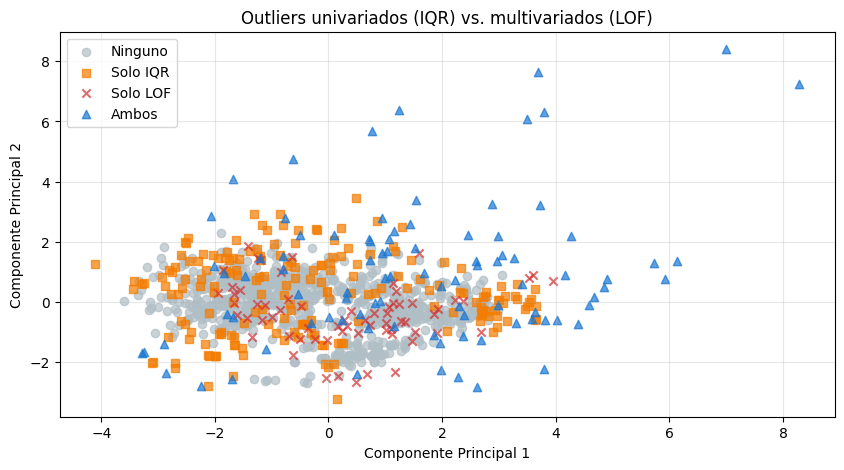

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # Import PCA
from IPython.display import display

# --- Visualizacion sobre la proyeccion PCA (celda anterior) ---
# El PCA se usa aca solo para graficar en 2D (rol de Unidad 1, U1-T-01 pp. 20-23),
# no para detectar: LOF ya corrio sobre las 9 variables originales estandarizadas,
# nunca sobre PC1/PC2 (U1-T-01 p. 21, argumento de la maldicion de la dimensionalidad).

# Perform PCA on the scaled data and add components to df_lof
pca = PCA(n_components=2)
pc = pca.fit_transform(datos_escalados)
df_lof['PC1'] = pc[:, 0]
df_lof['PC2'] = pc[:, 1]

# --- Comparacion: outliers univariados (IQR) vs. multivariados (LOF) ---
# LOF solo se calculo sobre las filas sin NaN (df_lof), mientras que el IQR
# se calculo sobre todo df_iqr. Restringimos la comparacion a df_lof.index
# para que sea 1 a 1 (misma logica que U2-T-01 pp. 15-21: comparar el mismo
# conjunto de observaciones bajo ambos criterios).
comparacion = pd.DataFrame({
    'outlier_iqr': df_iqr.loc[df_lof.index, 'outlier_iqr'],
    'outlier_lof': df_lof['outlier_lof']
})

# Tabla de contingencia (U1-T-01, pp. 7-10): outlier_iqr y outlier_lof son
# dos variables categoricas binarias, exactamente el caso de uso del capitulo.
tabla = pd.crosstab(comparacion['outlier_iqr'], comparacion['outlier_lof'])

# Test chi-cuadrado de independencia (U1-T-01, pp. 7-10). H0: los dos
# criterios de deteccion son independientes entre si.
chi2, p, gl, esperado = stats.chi2_contingency(tabla)
print(f"chi2 = {chi2:.2f}  gl = {gl}  p-valor = {p:.3g}\n")


# Reemplazamos print(tabla) por un Styler: mismos datos, pero renderizados
# como tabla real del notebook (con bordes, header y color) en vez de texto
# plano de consola — más fácil de leer para comparar IQR vs. LOF de un vistazo
tabla_estilizada = (
    tabla.style
    .set_caption('Tabla de contingencia')
    .background_gradient(cmap='Blues')
    .format(precision=0)
)
display(tabla_estilizada)

categoria = np.select(
    [comparacion['outlier_iqr'] & comparacion['outlier_lof'],
     comparacion['outlier_iqr'] & ~comparacion['outlier_lof'],
     ~comparacion['outlier_iqr'] & comparacion['outlier_lof']],
    ['Ambos', 'Solo IQR', 'Solo LOF'],
    default='Ninguno'
)

plt.figure(figsize=(10, 5))
for cat, color, marker in [('Ninguno', '#B0BEC5', 'o'), ('Solo IQR', '#F57C00', 's'),
                            ('Solo LOF', '#D32F2F', 'x'), ('Ambos', '#1976D2', '^')]:
    mask = categoria == cat
    plt.scatter(df_lof.loc[mask, 'PC1'], df_lof.loc[mask, 'PC2'],
                label=cat, alpha=0.7, marker=marker, c=color)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Outliers univariados (IQR) vs. multivariados (LOF)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El gráfico muestra que el IQR identifica una cantidad considerable de outliers de forma univariada, aunque varios de ellos no son considerados atípicos por LOF. Por su parte, LOF detecta menos observaciones como outliers exclusivos, pero incorpora el contexto de las variables y permite identificar casos que pueden no parecer extremos individualmente. La categoría “Ambos” concentra los casos donde coinciden ambos métodos, destacándose especialmente las observaciones ubicadas en las zonas más alejadas del conjunto principal. En conjunto, esto evidencia que el IQR y LOF capturan aspectos diferentes de los datos: mientras el IQR se basa en valores extremos de cada variable por separado, LOF considera la densidad y el entorno multivariado de cada observación.

##Sección 3.3

****

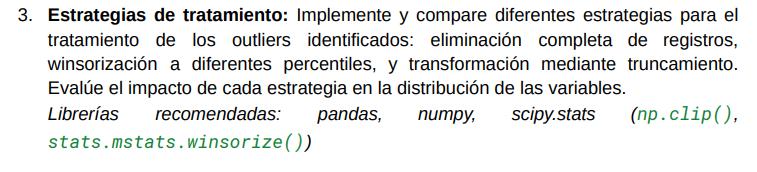

In [ ]:
def clasificar_naturaleza_outlier(es_outlier_iqr_var, es_outlier_lof):
    """Cruza el flag univariado (IQR, específico de una variable) con el
    multivariado (LOF, sobre el conjunto de 9 variables) para decidir
    tratamiento según el tipo de outlier: extremo aislado en esa columna
    vs. atípico en combinación con el resto vs. ambas cosas a la vez.
    Distingue aparte las filas que LOF nunca evaluó (dropna previo por
    faltantes en alguna de las 9 variables) — tratarlas como 'normal'
    sería incorrecto, no es que LOF las haya descartado, no las vio."""
    lof_alineado = es_outlier_lof.reindex(es_outlier_iqr_var.index)
    evaluado_por_lof = lof_alineado.notna()

    # reindex sube el dtype a float64 para poder representar los NaN de las
    # filas no evaluadas; volvemos a bool con un placeholder (False) que es
    # seguro porque esas filas ya quedan cubiertas por evaluado_por_lof antes
    # de llegar a usarse en las ramas que niegan/leen lof_alineado
    lof_bool = lof_alineado.fillna(False).astype(bool)

    categoria = pd.Series('normal', index=es_outlier_iqr_var.index)
    categoria[es_outlier_iqr_var & ~evaluado_por_lof] = 'solo_iqr_sin_lof'
    categoria[es_outlier_iqr_var & evaluado_por_lof & lof_bool] = 'ambos'
    categoria[es_outlier_iqr_var & evaluado_por_lof & ~lof_bool] = 'solo_iqr'
    categoria[~es_outlier_iqr_var & evaluado_por_lof & lof_bool] = 'solo_lof'
    return categoria


In [ ]:
categoria_lotarea = clasificar_naturaleza_outlier(outliers_iqr['LotArea'], df_lof['outlier_lof'])
categoria_lotarea.value_counts()
variables_outliers = [
    'LotFrontage', 'LotArea', 'OverallCond', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'GarageArea', 'PoolArea', 'SalePrice'
]

resumen_naturaleza = pd.DataFrame({
    variable: clasificar_naturaleza_outlier(outliers_iqr[variable], df_lof['outlier_lof']).value_counts()
    for variable in variables_outliers
}).fillna(0).astype(int)

resumen_naturaleza


/tmp/ipykernel_191/2314702079.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lof_bool = lof_alineado.fillna(False).astype(bool)
/tmp/ipykernel_191/2314702079.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lof_bool = lof_alineado.fillna(False).astype(bool)
/tmp/ipykernel_191/2314702079.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting'

,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageArea,PoolArea,SalePrice
ambos,30,29,19,3,0,14,12,6,30
normal,1247,1262,1198,1300,1304,1283,1295,1303,1273
solo_iqr,57,15,81,4,0,13,6,0,28
solo_iqr_sin_lof,0,27,25,0,0,8,3,1,3
solo_lof,128,129,139,155,158,144,146,152,128


In [ ]:
variables_tratamiento = ['LotFrontage', 'LotArea', 'SalePrice', 'GarageArea', 'YearBuilt', 'BedroomAbvGr']

In [ ]:
from scipy import stats
from scipy.stats import skew

# categorias_por_variable: análogo a limites_iqr, pero con la clasificación
# completa por fila (la celda de resumen_naturaleza solo hizo value_counts)
categorias_por_variable = {
    variable: clasificar_naturaleza_outlier(outliers_iqr[variable], df_lof['outlier_lof'])
    for variable in variables_tratamiento
}

# Proporción a recortar de cada cola en la winsorización
niveles_winsorizacion = {variable: (0.05, 0.05) for variable in variables_tratamiento}


def comparar_distribucion(original, tratada, nombre):
    """Compara la serie tratada contra la original con el test de
    Kolmogorov-Smirnov (dos muestras): cuantifica cuánto cambió la
    distribución, más allá de lo que muestra el boxplot a simple vista."""
    ks_stat, ks_pvalor = stats.ks_2samp(original.dropna(), tratada.dropna())
    return {
        'estrategia': nombre,
        'n': tratada.notna().sum(),
        'asimetria': skew(tratada.dropna()),
        'estadistico_ks': ks_stat,
        'p_valor_ks': ks_pvalor,
    }


def aplicar_tratamientos(df, variable, categorias_por_variable, limites_iqr, niveles_winsorizacion):
    """Aplica las tres estrategias sobre `variable` y devuelve un dict
    {nombre_estrategia: serie_tratada} para comparar. La eliminación usa
    específicamente la categoría 'ambos' (outlier según IQR y LOF a la
    vez) — el criterio que ya documenta el docstring de eliminar_outliers."""
    categorias = categorias_por_variable[variable]
    es_ambos = categorias == 'ambos'
    limite_inf, limite_sup = limites_iqr[variable]
    winsor_inf, winsor_sup = niveles_winsorizacion[variable]

    return {
        'Eliminación (outliers "ambos")': eliminar_outliers(df, es_ambos)[variable],
        'Winsorización': winsorizar(df[variable], winsor_inf, winsor_sup),
        'Truncamiento (límites IQR)': truncar(df[variable], limite_inf, limite_sup),
    }


/tmp/ipykernel_191/2314702079.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lof_bool = lof_alineado.fillna(False).astype(bool)
/tmp/ipykernel_191/2314702079.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lof_bool = lof_alineado.fillna(False).astype(bool)
/tmp/ipykernel_191/2314702079.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting'

In [ ]:
variables_tratamiento = ['LotFrontage', 'LotArea', 'SalePrice', 'GarageArea', 'YearBuilt', 'BedroomAbvGr']

def calcular_limites_iqr(serie):
    """1.5xIQR (regla de Tukey) — mismo criterio ya usado para armar
    'outliers_iqr' en la Sección 3.1, para que truncar() sea consistente
    con la detección que alimentó la clasificación de naturaleza."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

limites_iqr = {
    variable: calcular_limites_iqr(df[variable])
    for variable in variables_tratamiento
}
limites_iqr


{'LotFrontage': (np.float64(27.5), np.float64(111.5)),
 'LotArea': (np.float64(1476.0), np.float64(17700.0)),
 'SalePrice': (np.float64(4000.0), np.float64(340000.0)),
 'GarageArea': (np.float64(-24.0), np.float64(936.0)),
 'YearBuilt': (np.float64(1885.0), np.float64(2069.0)),
 'BedroomAbvGr': (np.float64(0.5), np.float64(4.5))}

In [ ]:
from scipy.stats import skew
from scipy.stats.mstats import winsorize

def eliminar_outliers(df, es_outlier):
    """Elimina por completo las filas marcadas en `es_outlier` (máscara
    booleana alineada al índice de df). Es la estrategia más agresiva:
    pierde toda la información de esas observaciones, no solo la variable
    problemática — por eso reservada para los casos con evidencia más
    fuerte (ej. categoría 'ambos' de la clasificación anterior)."""
    return df.loc[~es_outlier].copy()


def winsorizar(serie, limite_inferior, limite_superior):
    """Winsoriza los valores observados de la serie (reemplaza los extremos
    por el percentil de corte, no los elimina). Los faltantes quedan
    intactos: winsorizar y tratar NaN son problemas independientes, no
    corresponde imputar acá. Devuelve una copia."""
    serie_tratada = serie.copy()
    mascara_validos = serie.notna()
    serie_tratada[mascara_validos] = winsorize(
        serie[mascara_validos], limits=(limite_inferior, limite_superior)
    )
    return serie_tratada


def truncar(serie, limite_inferior, limite_superior):
    """Trunca (clip) los valores observados a un límite fijo, en vez de a un
    percentil relativo como winsorizar — la diferencia conceptual entre
    ambas es justamente eso: percentil de la muestra vs. umbral externo
    (acá, típicamente los límites IQR ya calculados). np.clip propaga NaN
    sin tocarlos, así que los faltantes también quedan intactos."""
    return pd.Series(
        np.clip(serie, limite_inferior, limite_superior),
        index=serie.index, name=serie.name,
    )


In [ ]:
tratamientos_por_variable = {}
tablas_comparacion_por_variable = {}

def analizar_tratamientos_variable(variable):
    """Corre tabla + boxplot + histogramas para una sola variable — pensada
    para tener una celda por variable, igual que el resto de la Sección 3.1,
    en vez de un loop que tira todo junto en una sola celda."""
    tratamientos = aplicar_tratamientos(df, variable, categorias_por_variable, limites_iqr, niveles_winsorizacion)
    tratamientos_por_variable[variable] = tratamientos

    tabla = pd.DataFrame([
        comparar_distribucion(df[variable], serie_tratada, nombre)
        for nombre, serie_tratada in tratamientos.items()
    ])
    tablas_comparacion_por_variable[variable] = tabla

    display(
        tabla.round(2).style
        .set_caption(f'Comparación de estrategias de tratamiento — {variable}')
        .background_gradient(subset=['estadistico_ks'], cmap='Reds')
    )

    datos_boxplot = pd.DataFrame({'Original': df[variable], **tratamientos})
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=datos_boxplot, orient='h')
    plt.title(f'{variable}: boxplot por estrategia de tratamiento')
    plt.tight_layout()
    plt.show()

    versiones = {'Original': df[variable], **tratamientos}
    fig, axes = plt.subplots(nrows=1, ncols=len(versiones), figsize=(4 * len(versiones), 3.5), sharey=True)
    for ax, (nombre, serie) in zip(axes, versiones.items()):
        #sns.histplot(serie.dropna(), kde=True, ax=ax, color='#4C72B0', bins=30)
        todos_los_datos = pd.concat(versiones.values()).dropna()
        bins = np.linspace(todos_los_datos.min(), todos_los_datos.max(), 31)

        for ax, (nombre, serie) in zip(axes, versiones.items()):
         sns.histplot(serie.dropna(), kde=True, ax=ax, bins=bins)
         ax.set_title(nombre, fontsize=9)
         ax.set_xlabel('')
         ax.set_title(nombre, fontsize=9)
         ax.set_xlabel('')
    fig.suptitle(f'{variable}: distribución por estrategia', y=1.03)
    plt.tight_layout()
    plt.show()


,estrategia,n,asimetria,estadistico_ks,p_valor_ks
0,"Eliminación (outliers ""ambos"")",1172,0.060000,0.020000,0.930000
1,Winsorización,1202,0.120000,0.050000,0.120000
2,Truncamiento (límites IQR),1202,0.090000,0.040000,0.340000


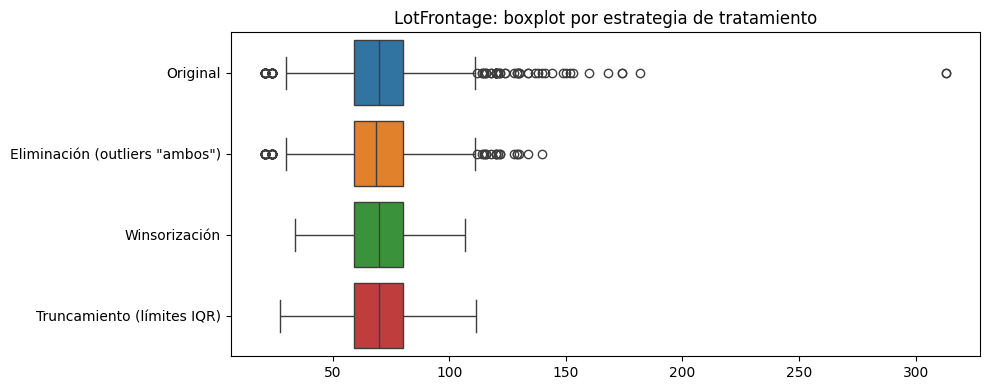

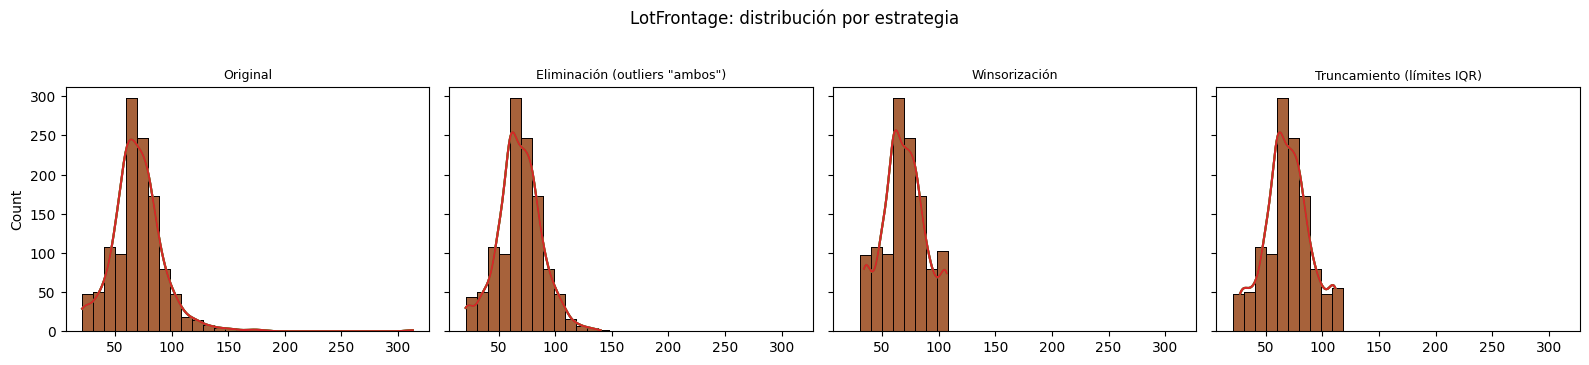

,estrategia,n,asimetria,estadistico_ks,p_valor_ks
0,"Eliminación (outliers ""ambos"")",1433,32.210000,0.020000,0.940000
1,Winsorización,1462,0.340000,0.050000,0.050000
2,Truncamiento (límites IQR),1462,0.220000,0.050000,0.070000


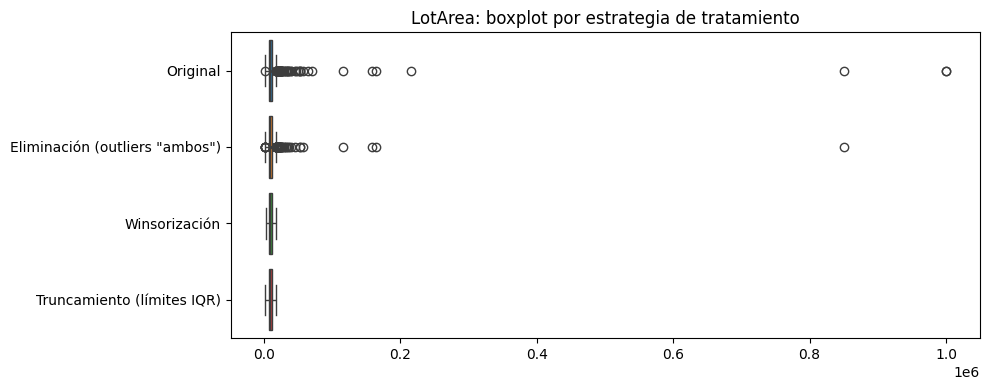

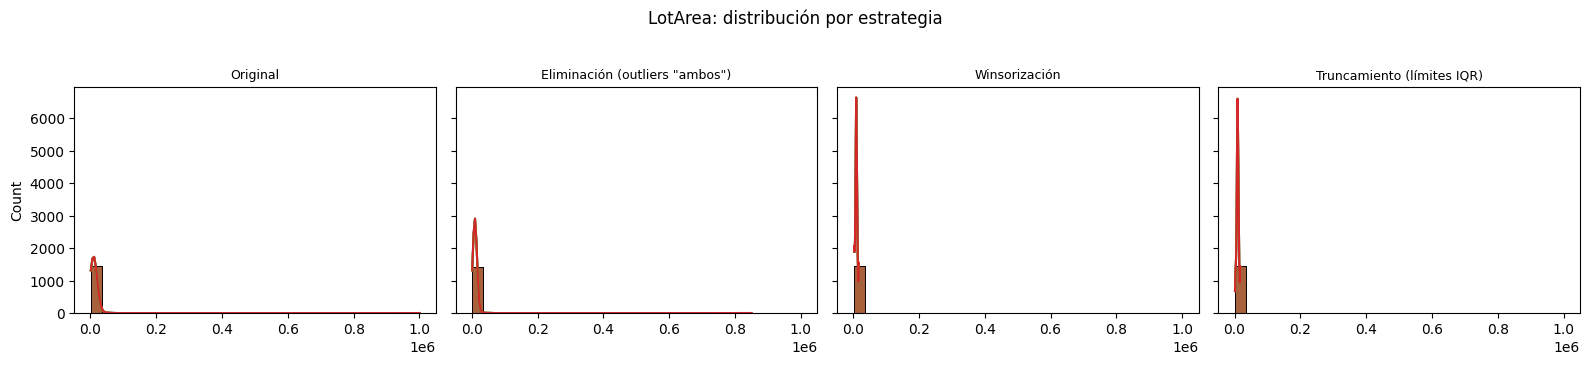

,estrategia,n,asimetria,estadistico_ks,p_valor_ks
0,"Eliminación (outliers ""ambos"")",1432,1.070000,0.020000,0.920000
1,Winsorización,1462,0.810000,0.050000,0.050000
2,Truncamiento (límites IQR),1462,0.800000,0.040000,0.160000


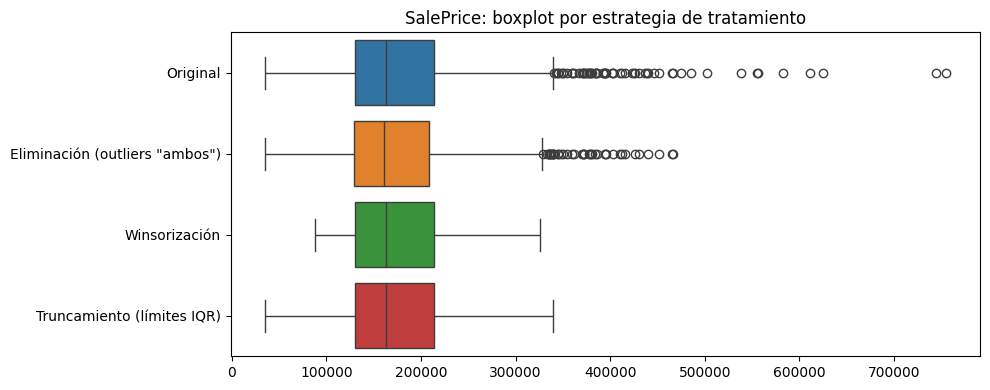

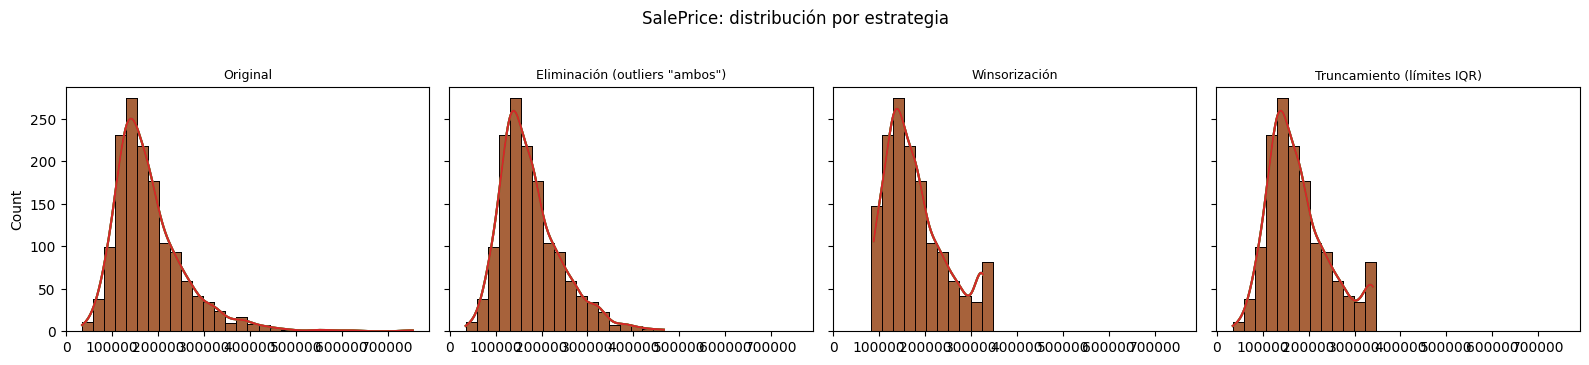

,estrategia,n,asimetria,estadistico_ks,p_valor_ks
0,"Eliminación (outliers ""ambos"")",1450,-0.040000,0.010000,1.000000
1,Winsorización,1462,-0.200000,0.050000,0.050000
2,Truncamiento (límites IQR),1462,-0.070000,0.010000,1.000000


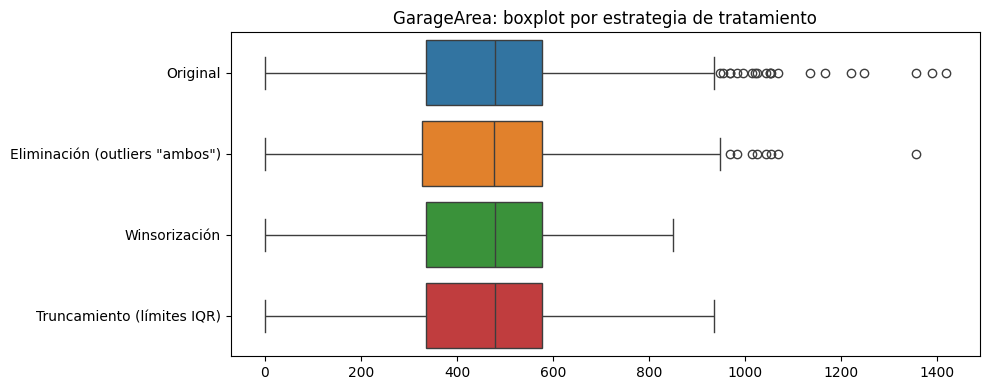

In [ ]:
analizar_tratamientos_variable('LotFrontage')
analizar_tratamientos_variable('LotArea')
analizar_tratamientos_variable('SalePrice')
analizar_tratamientos_variable('GarageArea')
analizar_tratamientos_variable('YearBuilt')
analizar_tratamientos_variable('BedroomAbvGr')

#Ejercicio 4

##Seccion 4.1

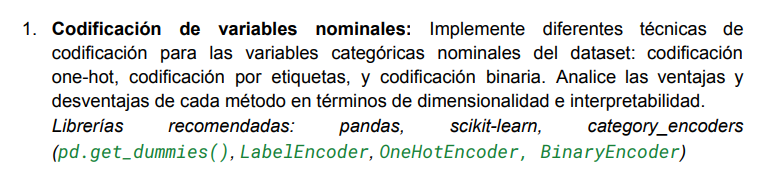

Variables nominales:



*   NeighborHood

*   MSZoning



In [ ]:
#Codificacion one-hot
df_one_hot = df.copy()
#Aplicar One-Hot Encoding
df_one_hot = pd.get_dummies(df_one_hot, columns=['Neighborhood', 'MSZoning'], dtype=int)

#Ver las columnas creadas
columnas_codificadas = [col for col in df_one_hot.columns if col.startswith(('Neighborhood_', 'MSZoning_'))]

#Mostrar las columnas codificadas
df_one_hot[columnas_codificadas].head(5)




In [ ]:
#Codificacion por etiquetas
df_label = df.copy()

#Crear los codificadores
le_neighborhood = LabelEncoder()
le_mszoning = LabelEncoder()

#Aplicar Label Encoding
df_label['Neighborhood'] = le_neighborhood.fit_transform(df_label['Neighborhood'])

df_label['MSZoning'] = le_mszoning.fit_transform(df_label['MSZoning'])

df_label[['Neighborhood', 'MSZoning']].head(5)

In [ ]:
#Codificacion binaria
df_binary =df.copy()

#Definir las columnas a codificar
columnas_categoricas = ['Neighborhood', 'MSZoning']

#Inicializar y aplicar el codificador
encoder = BinaryEncoder(cols=columnas_categoricas)
df_encoded = encoder.fit_transform(df_binary)

df_encoded.head(5)


Ventajas y Desventajas de cada método.

**One-hot Encoding:** Como principal ventaja podemos mencionar la interpretabilidad directa, ya que cada característica binaria corresponde de forma clara y explícita a una feature.

Sin embargo, esta técnica de codificación tiene como principal desventaja la llamada "maldición de la dimensionalidad". Si la variable categórica tiene una gran cantidad de valores únicos (alta cardinalidad), one-hot encoding generaría una matriz enorme que aumentaría drásticamente el costo computacional de almacenamiento, entrenamiento y predicción del modelo.

**Label Encoding:** La principal ventaja de esta codificación es que no expande la dimensionalidad del conjunto de datos, ya que condensa cualquier número de categorías en una sola columna numérica asignando valores de 0 a k-1.
Como desventaja, introduce un orden numérico espurio que distorsiona la interpretación del modelo, haciendo que relaciones inexistentes (como asumir que una categoría es mayor o menor que otra) afecten el significado de las predicciones y de los coeficientes.

**Binary Encoding:** Como principal ventaja frente a la alta cardinalidad, comprime notablemente el espacio de características al requerir solo log_2(k) columnas en lugar de k, evitando la creación de matrices masivas y dispersas.
Como desventaja, genera una pérdida total de interpretabilidad directa, ya que las nuevas columnas corresponden únicamente a bits posicionales del código binario (por ejemplo, "el segundo bit"), volviendo opaca la relación entre las características individuales y la variable objetivo.

##Seccion 4.2

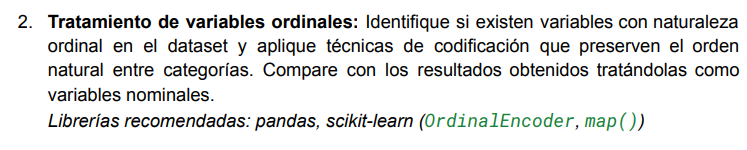

Variables Ordinales:

* OverallCond (codificada numericamente)
* GarageQual
* PoolQC
* Fence

In [ ]:
df_ordinal = df.copy()

#Diccionarios de codificación ordinal
garagequal_map = {
    'NONE': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

poolqc_map = {
    'NONE': 0,
    'Fa': 1,
    'TA': 2,
    'Gd': 3,
    'Ex': 4
}

fence_map = {
    'NONE': 0,
    'MnWw': 1,
    'GdWo': 2,
    'MnPrv': 3,
    'GdPrv': 4
}

#Aplicar la codificación
df_ordinal['GarageQual'] = df_ordinal['GarageQual'].map(garagequal_map)
df_ordinal['PoolQC'] = df_ordinal['PoolQC'].map(poolqc_map)
df_ordinal['Fence'] = df_ordinal['Fence'].map(fence_map)

In [ ]:
df_ordinal[['GarageQual', 'PoolQC', 'Fence']].tail(10)

In [ ]:
#Hacemos un one-hot encoding trartando las variables como nominales para comparar
df_onehot = df.copy()

df_onehot = pd.get_dummies(df_onehot, columns=['GarageQual', 'PoolQC', 'Fence'], dtype=int)

In [ ]:
df_onehot.filter(regex='^(GarageQual|PoolQC|Fence)_').head(10)

Al comparar ambos tratamientos, se observa que la codificación ordinal resulta más adecuada para estas variables, ya que permite conservar la jerarquía natural existente entre sus categorías. En cambio, aunque One-Hot Encoding puede aplicarse correctamente, transforma cada categoría en una variable independiente y, por lo tanto, elimina dicha relación de orden, perdiendo información relevante que puede ser aprovechada por el modelo.


##Seccion 4.3

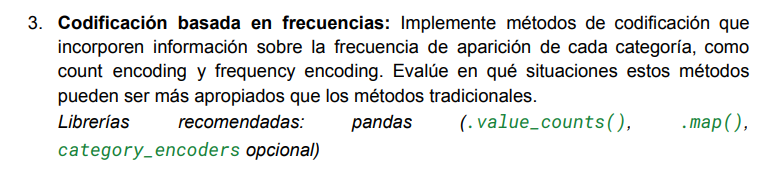

In [ ]:
columnas = [
    'Neighborhood',
    'MSZoning',
    'OverallCond',
    'GarageQual',
    'PoolQC',
    'Fence'
]

#Codificacion por conteo

df_count = df.copy()

#Conteo de cada categoría para cada variable
df_count['Neighborhood'] = df_count['Neighborhood'].map(df['Neighborhood'].value_counts())

df_count['MSZoning'] = df_count['MSZoning'].map(df['MSZoning'].value_counts())

df_count['OverallCond'] = df_count['OverallCond'].map(df['OverallCond'].value_counts())

df_count['GarageQual'] = df_count['GarageQual'].map(df['GarageQual'].value_counts())

df_count['PoolQC'] = df_count['PoolQC'].map(df['PoolQC'].value_counts())

df_count['Fence'] = df_count['Fence'].map(df['Fence'].value_counts())


df_count[columnas].head(10)

In [ ]:
#Codificacion por frequencia
df_frequency = df.copy()

#Frecuencia de cada categoría para cada variable
df_frequency['Neighborhood'] = df_frequency['Neighborhood'].map(df['Neighborhood'].value_counts(normalize=True))

df_frequency['MSZoning'] = df_frequency['MSZoning'].map(df['MSZoning'].value_counts(normalize=True))

df_frequency['OverallCond'] = df_frequency['OverallCond'].map(df['OverallCond'].value_counts(normalize=True))

df_frequency['GarageQual'] = df_frequency['GarageQual'].map(df['GarageQual'].value_counts(normalize=True))

df_frequency['PoolQC'] = df_frequency['PoolQC'].map(df['PoolQC'].value_counts(normalize=True))

df_frequency['Fence'] = df_frequency['Fence'].map(df['Fence'].value_counts(normalize=True))

df_frequency[columnas].head(10)

In [ ]:
#Tabla comparativa con una sola variable
comparacion = pd.DataFrame({
    'Original': df['Neighborhood'].head(10),
    'Count': df_count['Neighborhood'].head(10),
    'Frequency': df_frequency['Neighborhood'].head(10)
})

comparacion

La codificación por conteo y por frecuencia resulta especialmente conveniente para variables categóricas de alta cardinalidad, ya que permite representar cada variable mediante una única columna, evitando el aumento dimensional que produciría One-Hot Encoding. Además, al incorporar la frecuencia de aparición de cada categoría, puede proporcionar información útil para determinados modelos, especialmente los basados en árboles. A diferencia de las técnicas de codificación supervisadas, estos métodos no requieren utilizar la variable objetivo para generar la representación, reduciendo así el riesgo de fuga de información asociada al target.


# Ejercicio 5

 ## Seccion 5.1

MinMax: comprime todo al rango [0,1] usando mínimo y máximo. Muy sensible a outliers, porque un solo valor extremo distorsiona toda la escala.

Standard (z-score): centra en media 0 y desvío 1 — la media y el desvío también son sensibles a los outliers, aunque menos que MinMax.

Robust: usa mediana y rango intercuartílico en vez de media/desvío. Es el más resistente a los outliers.

In [ ]:
#Para no depender del ejercicio 2
columnas_knn = ['LotFrontage', 'GarageArea', 'PoolArea', 'BedroomAbvGr']
imputador_knn = KNNImputer(n_neighbors=5)  # mismos parámetros que ya usaron en la celda 46

df_imputado_array = imputador_knn.fit_transform(df[columnas_knn])
df_imputado = pd.DataFrame(df_imputado_array, columns=columnas_knn, index=df.index)

df['LotFrontage'] = df_imputado['LotFrontage']

# Verificación
df['LotFrontage'].isna().sum()


In [ ]:
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_numericas.remove('OverallCond')

df_numerico = df[columnas_numericas]
df_numerico.columns.tolist()

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_numerico),
    columns=df_numerico.columns, index=df_numerico.index
)
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_numerico),
    columns=df_numerico.columns, index=df_numerico.index
)
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_numerico),
    columns=df_numerico.columns, index=df_numerico.index
)

display(df_minmax.describe())
display(df_standard.describe())
display(df_robust.describe())

In [ ]:
variables_comparar = [
    'PoolArea', 'SalePrice', 'YearBuilt',
    'LotFrontage', 'LotArea', 'FullBath', 'BedroomAbvGr', 'GarageArea'
]
versiones = {
    'Original': df_numerico,
    'MinMax': df_minmax,
    'Standard': df_standard,
    'Robust': df_robust
}

fig, axes = plt.subplots(nrows=len(variables_comparar), ncols=4, figsize=(16, 4 * len(variables_comparar)))

for i, var in enumerate(variables_comparar):
    for j, (nombre, datos) in enumerate(versiones.items()):
        ax = axes[i, j]
        sns.histplot(datos[var], ax=ax, kde=True, bins=30, color='#5B9BD5')
        ax.set_title(f'{var} — {nombre}' if i == 0 else nombre, fontsize=10)
        if j == 0:
            ax.set_ylabel(var, fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.show()


##Seccion 5.2

In [ ]:
from scipy.stats import skew

asimetria = (
    df_numerico.apply(skew)
    .sort_values(ascending=False)
    .to_frame(name='Coeficiente de asimetría (skewness)')
)
asimetria


In [ ]:
muy_fuerte_asimetria = ['LotArea', 'PoolArea']
fuerte_asimetria = ['LotFrontage', 'SalePrice']
moderada_asimetria = ['YearBuilt']
poca_asimetria = ['BedroomAbvGr', 'GarageArea', 'FullBath']

#Decisiones en base a la naturaleza de las features:
#PoolArea: tiene muchos ceros y mucha asimetría. log y box-cox no funcionarán por los 0's. Usamos Yeo-johnson que supera este problema.
#LotArea: mucha asimetría y sin 0's. Se escoge log.
#SalePrice: asimetría fuerte y sin ceros: se escoge log.
#LotFrontage: asimetría fuerte y sin ceros. Usamos box-cox (para variar de log y ver los distintos métodos)
#YearBuilt: asímetría moderada. Usamos raíz cuadrada.
#El resto de features no presenta asimetría considerable.

In [ ]:
from scipy import stats

df_transformado = df_numerico.copy()

df_transformado['LotArea'] = np.log(df_numerico['LotArea'])

df_transformado['SalePrice'] = np.log(df_numerico['SalePrice'])

df_transformado['LotFrontage'], lambda_lotfrontage = stats.boxcox(df_numerico['LotFrontage'])
print(f"Lambda óptimo (Box-Cox) para LotFrontage: {lambda_lotfrontage:.4f}")

df_transformado['PoolArea'], lambda_poolarea = stats.yeojohnson(df_numerico['PoolArea'])
print(f"Lambda óptimo (Yeo-Johnson) para PoolArea: {lambda_poolarea:.4f}")

df_transformado['YearBuilt'] = np.sqrt(df_numerico['YearBuilt'])

#BedroomAbvGr, GarageArea, FullBath quedan sin tocar (ya están copiadas en df_transformado)

df_transformado.head()
#(un lambda cercano a 0 equivale aproximadamente a un log; cercano a 0.5, a una raíz cuadrada; cercano a 1, prácticamente no transforma).

In [ ]:
from scipy.stats import skew, kurtosis

variables_transformadas = ['LotArea', 'SalePrice', 'LotFrontage', 'PoolArea', 'YearBuilt']

# Tabla comparativa de asimetría y curtosis
comparacion = pd.DataFrame({
    'Asimetría (antes)': df_numerico[variables_transformadas].apply(skew),
    'Asimetría (después)': df_transformado[variables_transformadas].apply(skew),
    'Curtosis (antes)': df_numerico[variables_transformadas].apply(kurtosis),
    'Curtosis (después)': df_transformado[variables_transformadas].apply(kurtosis),
})
comparacion


A continuación, cada variable se estandarizó antes de graficar el Q-Q plot. Es solo para que la recta se asemeje a la y=x. Estandarizar es una transformación lineal que no modifica la forma de la distribución ni su asimetría. Solo recentra los datos en media 0 y desvío 1 para que la escala coincida con la de los cuantiles teóricos de la normal. Las conclusiones sobre qué tan bien corrigió cada transformación la asimetría son las mismas que se obtendrían sin este paso adicional.

In [ ]:
from scipy.stats import zscore

fig, axes = plt.subplots(nrows=len(variables_transformadas), ncols=2, figsize=(10, 4 * len(variables_transformadas)))

for i, var in enumerate(variables_transformadas):
    stats.probplot(zscore(df_numerico[var]), dist='norm', plot=axes[i, 0])
    axes[i, 0].set_title(f'{var} — Antes (estandarizado)')

    stats.probplot(zscore(df_transformado[var]), dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(f'{var} — Después (estandarizado)')

plt.tight_layout()
plt.show()



##Seccion 5.3

In [ ]:
from scipy.stats import shapiro

variables_transformadas = ['LotArea', 'SalePrice', 'LotFrontage', 'PoolArea', 'YearBuilt']

# Histogramas antes/después
fig, axes = plt.subplots(nrows=len(variables_transformadas), ncols=2, figsize=(10, 4 * len(variables_transformadas)))
for i, var in enumerate(variables_transformadas):
    sns.histplot(df_numerico[var], ax=axes[i, 0], kde=True, color='#B0BEC5')
    axes[i, 0].set_title(f'{var} — Antes')
    sns.histplot(df_transformado[var], ax=axes[i, 1], kde=True, color='#5B9BD5')
    axes[i, 1].set_title(f'{var} — Después')
plt.tight_layout()
plt.show()

# Test de Shapiro-Wilk: cuantifica formalmente la normalidad
resultados_shapiro = []
for var in variables_transformadas:
    stat_antes, p_antes = shapiro(df_numerico[var])
    stat_despues, p_despues = shapiro(df_transformado[var])
    resultados_shapiro.append({
        'Variable': var,
        'W (antes)': stat_antes, 'p-valor (antes)': p_antes,
        'W (después)': stat_despues, 'p-valor (después)': p_despues,
    })

pd.DataFrame(resultados_shapiro).set_index('Variable')


*   Claramente se observa que los tests rechazan la hipótesis nula de distribuciones normales. Es común pues las originales tenían asimetrías considerables. Sin embargo, nótese que el estadístico W (que va de 0 a 1) si cambió. Salvo en PoolArea y Yearbuilt (con variaciones mínimas) todos se han acercado a 1. Un W más cerca a 1 indica mayor similitud con una distribución normal.
*   El caso de PoolArea: ninguna transformación resolvió su naturaleza zero-inflated. Sugerencia (a chequear): para casi cualquier modelo probablemente convenga más una variable binaria (tiene_pileta) que insistir con una versión continua transformada. Y el caso de YearBuilt (cola hacia la izquierda) confirma que aplicar una transformación sin verificar la dirección de la asimetría no es una acción neutra — puede no aportar nada o empeorar levemente la distribución, sin beneficio para ningún tipo de modelo.
(log y raíz se especializan en asimetrías hacia la derecha).


#Ejercicio 6

##Seccion 6.1
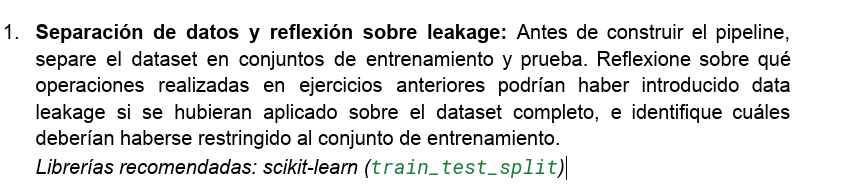

Si se hubieran aplicado las operaciones de los ejercicios previos directamente sobre el dataset completo, se habrían introducido fugas de datos (data leakage) masivas, generando estimaciones de rendimiento del modelo excesivamente optimistas y poco realistas. Específicamente, las siguientes operaciones deberían haberse restringido al conjunto de entrenamiento:

 Imputación de valores faltantes (Estadística y kNN): Calcular la media, la moda o ajustar un KNNImputer utilizando todo el conjunto de datos provoca que las estadísticas aprendidas incluyan propiedades del conjunto de prueba. Todo ajuste de parámetros (el método fit) de cualquier estimador debe realizarse únicamente sobre los datos de entrenamiento para luego transformar (transform) ambos conjuntos.  

 Codificación categórica (pd.get_dummies()): Aplicar la codificación One-Hot sobre el DataFrame completo permite conocer de antemano todas las categorías únicas existentes. Esto es un error, ya que una categoría podría aparecer exclusivamente en el conjunto de prueba, por lo que se recomienda utilizar OneHotEncoder sobre el conjunto de entrenamiento y configurar reglas (como ignorar categorías desconocidas) para los datos nuevos.

  Detección y tratamiento de Outliers (IQR y LOF): Las transformaciones que dependen del estado de los datos (como calcular percentiles, desviación estándar o la mediana para el escalado robusto) deben calcularse exclusivamente a partir del conjunto de entrenamiento. Si los umbrales de winsorización o truncamiento se calculan con el dataset entero, el modelo estará "contaminado" con el conocimiento de los valores extremos del test.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Define features (X) and target (y)
X = df_pipeline.drop('SalePrice', axis=1)
y = df_pipeline['SalePrice']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##Seccion 6.2 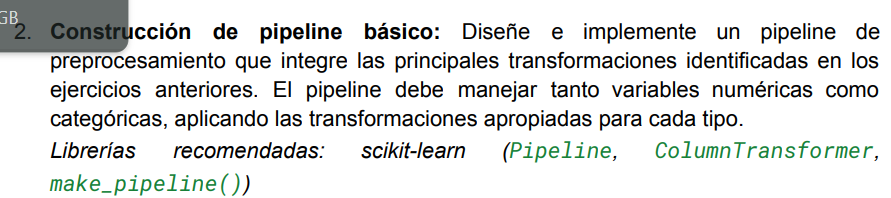
![image.png](data:image/png;...)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

# Definir listas de columnas según la naturaleza de los datos
numeric_features = [
    'LotFrontage', 'LotArea', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'GarageArea', 'PoolArea'
]

nominal_features = ['Neighborhood', 'MSZoning']
ordinal_features = ['GarageQual', 'PoolQC', 'OverallCond','Fence']

# Crear sub-pipelines para cada tipo de dato
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('power_transform', PowerTransformer(method='yeo-johnson'))
])

categorical_nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='NONE')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='NONE')),

    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combinar los sub-pipelines usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_nom', categorical_nominal_transformer, nominal_features),
        ('cat_ord', categorical_ordinal_transformer, ordinal_features)
    ],
    remainder='drop'
)

"""final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])"""
final_pipeline  = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

final_pipeline.fit(X_train, y_train)

score_train = final_pipeline.score(X_train, y_train)
score_test = final_pipeline.score(X_test, y_test)

print(f"R² en Entrenamiento: {score_train:.3f}")
print(f"R² en Prueba: {score_test:.3f}")

final_pipeline

NameError: name 'Ridge' is not defined

##Seccion 6.3
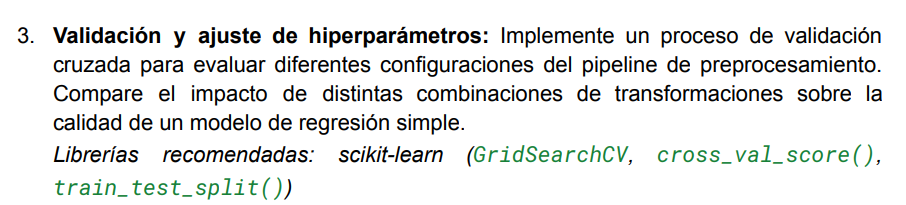

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer

# Definir el Pipeline base con un modelo de regresión simple
pipeline_regresion = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

# Evaluación inicial con cross_val_score
# Garantiza que el preprocesamiento se ajuste solo en los datos de entrenamiento de cada fold.
scores_base = cross_val_score(pipeline_regresion, X_train, y_train, cv=5, scoring='r2')
print("--- Rendimiento Base ---")
print(f"R² Promedio en CV: {scores_base.mean():.3f} (+/- {scores_base.std() * 2:.3f})\n")

# Definir el espacio de búsqueda (Grid Search)
# Usamos la sintaxis 'nombredelpaso__parametro' para acceder a los componentes internos del pipeline.
param_grid = {
    # Evaluamos qué escalador funciona mejor para nuestros datos[cite: 2]
    'preprocessor__num__scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],

    # Evaluamos el impacto del modelo de regresión (ajustando la regularización)
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}

# Configurar y ejecutar GridSearchCV
# Entrenará y evaluará un modelo para cada combinación utilizando validación cruzada[cite: 2].
grid_search = GridSearchCV(
    pipeline_regresion,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1 # Usa todos los núcleos del procesador para ir más rápido
)

print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)

# Resultados de la optimización
print("\n--- Resultados de GridSearchCV ---")
print(f"Mejor R² en Validación Cruzada: {grid_search.best_score_:.3f}")
print("Mejor configuración encontrada:")
for parametro, valor in grid_search.best_params_.items():
    print(f" - {parametro}: {valor}")

# Evaluación final sobre el conjunto de prueba (que mantuvimos aislado)
# El predict aplicará automáticamente todas las transformaciones aprendidas al X_test[cite: 2].
score_test_final = grid_search.score(X_test, y_test)
print(f"\nR² Final en el conjunto de prueba aislado: {score_test_final:.3f}")

--- Rendimiento Base ---
R² Promedio en CV: 0.711 (+/- 0.063)

Iniciando búsqueda de hiperparámetros...

--- Resultados de GridSearchCV ---
Mejor R² en Validación Cruzada: 0.711
Mejor configuración encontrada:
 - preprocessor__num__scaler: StandardScaler()
 - regressor__alpha: 1.0

R² Final en el conjunto de prueba aislado: 0.655


##Seccion 6.4
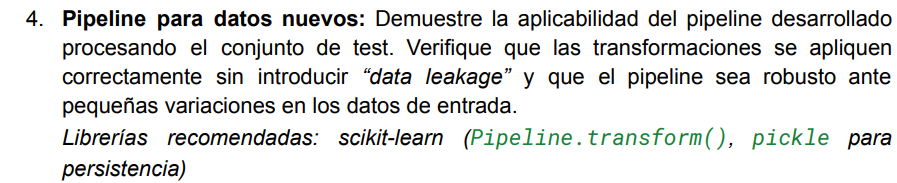

In [ ]:
import pickle
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Guardamos el mejor modelo encontrado por GridSearchCV en un archivo binario.
nombre_archivo = 'pipeline_house_prices_final.pkl'

with open(nombre_archivo, 'wb') as file:
    pickle.dump(grid_search.best_estimator_, file)

print("Pipeline exportado exitosamente como ", nombre_archivo)

# Cargamos el pipeline desde el archivo como si estuviéramos en un servidor nuevo.
with open(nombre_archivo, 'rb') as file:
    pipeline_produccion = pickle.load(file)

print(" Pipeline cargado en memoria listo para producción.")

y_pred_test = pipeline_produccion.predict(X_test)

r2_final = r2_score(y_test, y_pred_test)
mse_final = mean_squared_error(y_test, y_pred_test)
rmse_final = np.sqrt(mse_final)

print("\n--- Rendimiento Final en Datos No Vistos (Test Set) ---")
print(f"R²: {r2_final:.3f}")
print(f"RMSE (Raiz del Error Cuadrático Medio): ${rmse_final:,.2f}")

print("\nNota de Robustez:")
print("El pipeline procesó X_test sin errores. Si apareció un 'Neighborhood' o 'MSZoning")
print("que no existía en el entrenamiento, el OneHotEncoder (gracias a handle_unknown='ignore')")
print("lo codificó con ceros sin romper la ejecución, demostrando estabilidad ante variaciones.")

Pipeline exportado exitosamente como  pipeline_house_prices_final.pkl
 Pipeline cargado en memoria listo para producción.

--- Rendimiento Final en Datos No Vistos (Test Set) ---
R²: 0.655
RMSE (Raiz del Error Cuadrático Medio): $48,100.77

Nota de Robustez:
El pipeline procesó X_test sin errores. Si apareció un 'Neighborhood' o 'MSZoning
que no existía en el entrenamiento, el OneHotEncoder (gracias a handle_unknown='ignore')
lo codificó con ceros sin romper la ejecución, demostrando estabilidad ante variaciones.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define features (these were missing from this cell)
numeric_features = [
    'LotFrontage', 'LotArea', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'GarageArea', 'PoolArea'
]

nominal_features = ['Neighborhood', 'MSZoning']
ordinal_features = ['GarageQual', 'PoolQC', 'OverallCond','Fence']

# Transformador Personalizado para Outliers (Previene Data Leakage)
class TratamientoOutliers(BaseEstimator, TransformerMixin):
    def __init__(self, estrategia='passthrough', lower_q=0.05, upper_q=0.95):
        self.estrategia = estrategia
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        # Aprende los límites (cuartiles) ÚNICAMENTE usando los datos de entrenamiento
        X_df = pd.DataFrame(X)
        self.limites_inf_ = X_df.quantile(self.lower_q).values
        self.limites_sup_ = X_df.quantile(self.upper_q).values
        return self

    def transform(self, X):
        if self.estrategia == 'passthrough':
            return X # No hace nada, deja los datos originales

        X_trans = pd.DataFrame(X).copy()
        for i in range(X_trans.shape[1]):
            if self.estrategia == 'clipping':
                # El clipping reemplaza los valores extremos por los límites aprendidos
                X_trans.iloc[:, i] = np.clip(X_trans.iloc[:, i], self.limites_inf_[i], self.limites_sup_[i])
        return X_trans.values

# 2. Re-definir los sub-pipelines (usamos placeholders que GridSearchCV reemplazará)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Se probará reemplazar con KNNImputer
    ('outliers', TratamientoOutliers()),           # Se probará 'clipping' vs 'passthrough'
    ('scaler', StandardScaler()),                  # Se probará reemplazar con MinMax o Robust
    ('power_transform', PowerTransformer(method='yeo-johnson'))
])

categorical_nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='NONE')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='NONE')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_nom', categorical_nominal_transformer, nominal_features),
        ('cat_ord', categorical_ordinal_transformer, ordinal_features)
    ],
    remainder='drop'
)

# 4. Pipeline Final
pipeline_regresion = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

# 5. EL DICCIONARIO MÁGICO: El Espacio de Búsqueda de Estrategias
param_grid = {
    # Probar diferentes algoritmos de imputación numérica
    'preprocessor__num__imputer': [SimpleImputer(strategy='median'), KNNImputer(n_neighbors=5)],

    # Probar si conviene hacer clipping de outliers o dejarlos como están (passthrough)
    'preprocessor__num__outliers__estrategia': ['passthrough', 'clipping'],

    # Probar la sensibilidad a los distintos métodos de escalado
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],

    # Probar distintos niveles de penalización en la regresión
    'regressor__alpha': [0.1, 1.0, 10.0]
}

# 6. Ejecutar GridSearchCV
grid_search = GridSearchCV(
    pipeline_regresion,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1 # Muestra el progreso de los entrenamientos
)

print("Iniciando torneo de estrategias (Grid Search)...")
grid_search.fit(X_train, y_train)

# 7. Imprimir la "Receta Ganadora"
print("\n🏆 Mejor R² en CV:", round(grid_search.best_score_, 3))
print("🥇 Mejor configuración de preprocesamiento encontrada:")
for param, valor in grid_search.best_params_.items():
    print(f" - {param}: {valor}")

Iniciando torneo de estrategias (Grid Search)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

🏆 Mejor R² en CV: 0.711
🥇 Mejor configuración de preprocesamiento encontrada:
 - preprocessor__num__imputer: SimpleImputer(strategy='median')
 - preprocessor__num__outliers__estrategia: passthrough
 - preprocessor__num__scaler: StandardScaler()
 - regressor__alpha: 1.0
